# Advanced RAG Architectures For Improving Retrieval In Digital Archives

## 1. Introduction

This notebook implements and evaluates four Retrieval-Augmented Generation (RAG) approaches on the Viet Doc VQA dataset. Each RAG variant introduces different retrieval strategies and reasoning capabilities, allowing us to compare their effectiveness under a unified experimental framework.

Specifically, we will implement the following:

### Baseline RAG:
A standard RAG pipeline consisting of:
  - Embedding the query.
  - Retrieving top-K chunks from Qdrant.
  - Passing the retrieved chunks to the LLM to generate the final answer.

This serves as the foundation for comparison.

---

### Agentic RAG
An enhanced RAG workflow where the LLM acts as an agent and performs multiple reasoning steps:

- Rewrite the user query to improve retrievability
- Retrieve candidate chunks from Qdrant
- Critique the retrieved chunks (good/bad, sufficient/insufficient)
- Decide whether additional retrieval is needed
- Filter out irrelevant or low-quality chunks
- Generate the final answer using only the filtered set

This version tests how far LLM-driven reasoning can improve retrieval accuracy.

---

### Graph RAG
A RAG workflow augmented with a knowledge graph built from the dataset:

- Construct a Neo4j-based knowledge graph from extracted entities and relationships
- Parse the user query and extract key concepts
- Retrieve relevant nodes and linked document IDs from the graph
- Use these graph-derived candidates to guide retrieval from Qdrant
- Generate output based on retrieved vector-space chunks

This allows retrieval to leverage structured semantic relationships rather than pure embeddings.

---

### Hybrid RAG (Graph + Agentic)
A unified pipeline that combines the strengths of Graph RAG and Agentic RAG:

- The LLM first decides whether the query is best served by knowledge-graph retrieval or vector retrieval
- Then follows the same reasoning workflow as Agentic RAG:
  - Query rewriting
  - Retrieval and re-retrieval if needed
  - Chunk critique and filtering
  - Answer generation using filtered context

This hybrid approach evaluates whether dynamic retrieval-source selection improves robustness.

---

### Evaluation Method

All RAG systems implemented in this notebook will be evaluated using the following metrics:

1. Precision – Proportion of retrieved items that are relevant

2. Recall (Capped Recall) – Proportion of relevant items retrieved, capped with respect to K to handle large topic sizes

3. F1-score – Harmonic mean of precision and recall

4. Hit Rate – Whether at least one relevant item appears in the retrieved set

5. Execution Time – Total latency of the retrieval + generation pipeline

These metrics provide a consistent and fair basis for comparing retrieval effectiveness and efficiency across all RAG variants.

---
Tech Stack

- Vector Database: Qdrant
- Graph Database: Neo4j
- Embedding Model: text-embedding-3-small (OpenAI)
- LLM: gpt-4.1 (OpenAI)
- Dataset: Viet Doc VQA (via Hugging Face)
- OCR Engine: Tesseract for Vietnamese text extraction

---

This notebook serves as a controlled experimental environment for implementing, analyzing, and comparing the four RAG paradigms—Baseline, Agentic, Graph-based, and Hybrid—to understand their strengths, weaknesses, and practical trade-offs.

### 1.1. Install and Import Libraries

In [ ]:
!pip install ipywidgets
!pip install datasets
!pip install qdrant-client pillow tqdm pytesseract python-dotenv openai
!pip install neo4j
!apt-get install tesseract-ocr tesseract-ocr-vie -y

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached huggingface_hub-1.2.3-py3-none-any.whl.metadata (13 kB)
Using cached huggingface_hub-1.2.3-py3-none-any.whl (520 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.20.3
    Uninstalling huggingface-hub-0.20.3:
      Successfully uninstalled huggingface-hub-0.20.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tokenizers 0.15.2 requires huggingface_hub<1.0,>=0.16.4, but you have huggingface-hub 1.2.3 which is incompatible.
transformers 4.38.2 requires huggingface-hub<1.0,>=0.19.3, but you have huggingface-hub 1.2.3 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
'apt-get' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# ============================================
# 1. Standard Library
# ============================================
import base64
import json
import os
import platform
import random
import shutil
import time

# ============================================
# 2. Third-Party Libraries
# ============================================

# --- Data Handling & Analysis ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm

# --- Image Processing / OCR ---
from PIL import Image
import pytesseract

# --- Vector Database (Qdrant) ---
from qdrant_client import QdrantClient
from qdrant_client.http import models

# --- Graph Database (Neo4j) ---
from neo4j import GraphDatabase

# --- Authentication / API / Environment ---
from dotenv import load_dotenv
from huggingface_hub import login
from openai import OpenAI, RateLimitError

# ============================================
# 3. Load Environment Variables
# ============================================
load_dotenv()

True

### 1.2. Configure Tesseract

Tesseract’s installation path varies depending on the operating system (Windows, macOS, Linux), and the notebook must explicitly point to the correct binary location.

Proper configuration ensures that OCR runs reliably across different environments before we begin extracting text for RAG preprocessing.

In [ ]:
def configure_tesseract():
    system = platform.system()

    print(f"Detected OS: {system}")

    # --- Windows ---
    if system == "Windows":
        possible_paths = [
            r"C:\Program Files\Tesseract-OCR\tesseract.exe",
            r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe"
        ]

        for path in possible_paths:
            if os.path.exists(path):
                pytesseract.pytesseract.tesseract_cmd = path
                print(f"Using Tesseract at: {path}")
                return

        # Last resort: try PATH
        found = shutil.which("tesseract")
        if found:
            pytesseract.pytesseract.tesseract_cmd = found
            print(f"Using Tesseract from PATH: {found}")
            return

        raise FileNotFoundError("Tesseract not found on Windows. Install from: https://github.com/UB-Mannheim/tesseract/wiki")

    # --- Linux ---
    elif system == "Linux":
        path = shutil.which("tesseract")
        if path:
            pytesseract.pytesseract.tesseract_cmd = path
            print(f"Using Tesseract at: {path}")
            return
        else:
            raise FileNotFoundError("Tesseract not found on Linux. Install with: sudo apt install tesseract-ocr")

    # --- macOS ---
    elif system == "Darwin":
        # Common Homebrew locations
        possible_paths = [
            "/usr/local/bin/tesseract",
            "/opt/homebrew/bin/tesseract"
        ]

        for path in possible_paths:
            if os.path.exists(path):
                pytesseract.pytesseract.tesseract_cmd = path
                print(f"Using Tesseract at: {path}")
                return

        path = shutil.which("tesseract")
        if path:
            pytesseract.pytesseract.tesseract_cmd = path
            print(f"Using Tesseract from PATH: {path}")
            return

        raise FileNotFoundError("Install Tesseract on macOS using: brew install tesseract")

    else:
        raise OSError(f"Unsupported OS: {system}")

In [ ]:
configure_tesseract()

Detected OS: Windows
Using Tesseract at: C:\Program Files\Tesseract-OCR\tesseract.exe


### 1.3. Environment Setup & Service Initialization

#### 1.3.1. Google Colab Setup

Run this section if you are running this notebook on Google Colab. Otherwise, run section 1.3.2.

In [ ]:
from google.colab import userdata

In [ ]:
HUGGING_FACE_TOKEN = userdata.get("HUGGING_FACE_TOKEN")

QDRANT_CLUSTER_URL = userdata.get("QDRANT_CLUSTER_URL")
QDRANT_CLUSTER_API_KEY = userdata.get("QDRANT_CLUSTER_API_KEY")
COLLECTION_NAME = "viet-doc-vqa"

In [ ]:
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
EMBED_MODEL = "text-embedding-3-small"
EMBED_DIM = 1536

client_openai = OpenAI(api_key=OPENAI_API_KEY)

In [ ]:
qdrant_client = QdrantClient(
    url=QDRANT_CLUSTER_URL,
    api_key=QDRANT_CLUSTER_API_KEY,
)

print(qdrant_client.get_collections())

In [ ]:
NEO4J_URI = userdata.get("NEO4J_URI")
NEO4J_USER = userdata.get("NEO4J_USER")
NEO4J_PASSWORD = userdata.get("NEO4J_PASSWORD")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()

#### 1.3.2. Local Setup

In [ ]:
HUGGING_FACE_TOKEN = os.getenv("HUGGING_FACE_TOKEN")

QDRANT_CLUSTER_URL = os.getenv("QDRANT_CLUSTER_URL")
QDRANT_CLUSTER_API_KEY = os.getenv("QDRANT_CLUSTER_API_KEY")
COLLECTION_NAME = "viet-doc-vqa"

In [ ]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
EMBED_MODEL = "text-embedding-3-small"
EMBED_DIM = 1536

client_openai = OpenAI(api_key=OPENAI_API_KEY)


In [ ]:
qdrant_client = QdrantClient(
    url=QDRANT_CLUSTER_URL,
    api_key=QDRANT_CLUSTER_API_KEY,
)

print(qdrant_client.get_collections())

collections=[CollectionDescription(name='viet-doc-vqa')]


In [ ]:
NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USER = os.getenv("NEO4J_USER")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()

## 2. Data Preparation
Source: https://huggingface.co/datasets/5CD-AI/Viet-Doc-VQA

---

The Viet Doc VQA Dataset is a Vietnamese document–image collection designed for question answering and document understanding tasks. It contains over 51,000 annotated samples of textbook and official document pages, each paired with structured descriptions and question–answer pairs derived from the page content.

This dataset is particularly appropriate for studying RAG systems because:

- Each document contains rich textual information (OCR text, descriptions, QA pairs), enabling evaluation of retrieval quality across diverse content types.
- The dataset structure naturally supports query-to-document relevance, which is essential for measuring precision, recall, hit rate, and other retrieval metrics.
- The presence of multiple questions per page allows us to test how different RAG methods handle varied information needs over the same underlying document.

Overall, the dataset provides a realistic and sufficiently challenging benchmark for evaluating baseline, agentic, graph-based, and hybrid RAG approaches.

### 2.1. Load Dataset

The Viet Doc VQA dataset is gated on HuggingFace, so authentication is required to access it.
To set up your HuggingFace access token, refer to the instructions in the accompanying `README.md` file.

In [ ]:
# Authenticate to Hugging Face
login(token=HUGGING_FACE_TOKEN)

In [ ]:
dataset = load_dataset("5CD-AI/Viet-Doc-VQA", token=HUGGING_FACE_TOKEN)

dataset

Using the latest cached version of the dataset since 5CD-AI/Viet-Doc-VQA couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Admin\.cache\huggingface\datasets\5CD-AI___viet-doc-vqa\default\0.0.0\c8b32e5c4fe4cbafd79848683ec21c4c0f090d35 (last modified on Wed Dec 10 16:12:25 2025).


DatasetDict({
    train: Dataset({
        features: ['id', 'image', 'description', 'conversations'],
        num_rows: 51856
    })
})

In [ ]:
dataset["train"][0]

{'id': 0,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=700x1003>,
 'description': 'Bức ảnh là trang bìa của một cuốn sách. Ở phần trên cùng của trang, có dòng chữ "Bộ Giáo dục và Đào tạo" được in đậm, cỡ chữ lớn. Dưới dòng chữ này là danh sách các cá nhân biên tập cuốn sách: "PHAN TRỌNG LUÂN (Tổng Chủ biên) - TRẦN ĐĂNG SUYÊN (Chủ biên phần Văn) - BÙI MINH TOÀN (Chủ biên phần Tiếng Việt) - LÊ A (Chủ biên phần  Âm  văn) - LÊ  NGUYÊN  CÂN - ĐẶNG ANH ĐÀO - NGUYỄN THỊ NGÂN HOA - NGUYỄN THÁI HOÀ - ĐỖ KIM HỒI - NGUYỄN XUÂN NAM - ĐOÀN ĐỨC PHƯƠNG - NGUYỄN PHƯƠNG - VŨ DƯƠNG QUÝ".  Phần chính giữa trang là tựa đề cuốn sách được in chữ to, cỡ chữ lớn nhất trên trang: "Ngữ văn 12", dưới tựa đề là "Tập một"  và "(Tái bản lần thứ ba)". Ở cuối trang, dòng chữ "NHÀ XUẤT BẢN GIÁO DỤC VIỆT NAM" được in đậm.',
 'conversations': [{'role': 'user',
   'content': 'Cuốn sách trong ảnh thuộc bộ môn học nào?'},
  {'role': 'assistant',
   'content': 'Cuốn sách trong ảnh thuộc bộ môn Ngữ văn.'}

### 2.2. Prepare, Classify, Embed, and Index Data in Qdrant

In this section, we transform the Viet Doc VQA dataset into a structured and searchable form suitable for all RAG experiments. Each dataset entry is processed, enriched, and stored in the vector database through the following steps:

1. Extract relevant information from each dataset entry
    - Run OCR on the document image to obtain Vietnamese text
    - Retrieve the description field
    - Parse question–answer pairs from the conversation history
    - Combine these components into a unified `full_text` field

2. Classify each document into one of 18 Vietnamese school subjects (or topics)
    - Use OpenAI's LLM to categorize the document based on its description and QA content
    - Store this subject label as additional metadata to support subject-aware retrieval and analysis

3. Generate embeddings for each enriched RAG document
    - Use the `text-embedding-3-small` embedding model
    - Convert the `full_text` into a dense vector for similarity-based retrieval

4. Upsert all processed documents into Qdrant
    - Create the collection if it does not already exist
    - Create a custom index on id for later id-related retrieval
    - Batch-upload points containing:
        - The vector embedding
        - The original content (description, OCR text, QA pairs, topics) as payload
    - Ensure all dataset splits (train/validation/test) are indexed

This section converts raw dataset entries into classified, embedded, and indexed records, forming a robust retrieval-ready knowledge base for evaluating all RAG approaches in the notebook.

#### 2.2.1. Extract Relevant Information

In [ ]:
def run_ocr(image: Image.Image) -> str:
    """Extract OCR text from an image using Vietnamese language."""
    try:
        text = pytesseract.image_to_string(image, lang="vie")
        return text.strip()
    except Exception as e:
        print("OCR failed:", e)
        return ""

In [ ]:
def extract_qa(conversations):
    """Extract a list of (question, answer) pairs from conversation list."""
    qa_pairs = []
    current_q = None

    for turn in conversations:
        if turn["role"] == "user":
            current_q = turn["content"]
        elif turn["role"] == "assistant" and current_q is not None:
            qa_pairs.append((current_q, turn["content"]))
            current_q = None

    return qa_pairs


In [ ]:
rag_docs = []

for split in ["train", "validation", "test"]:
    if split not in dataset:
        continue

    for row in tqdm(dataset[split], desc=f"Processing {split}"):

        img: Image.Image = row["image"]
        ocr_text = run_ocr(img)

        description = row.get("description", "").strip()

        qa_pairs = extract_qa(row["conversations"])

        # Build full text for RAG
        qa_text = "\n".join([f"Q: {q}\nA: {a}" for q, a in qa_pairs])

        full_text = (
            f"DESCRIPTION:\n{description}\n\n"
            f"OCR:\n{ocr_text}\n\n"
        )

        rag_docs.append({
            "id": row["id"],
            "description": description,
            "ocr_text": ocr_text,
            "qa_pairs": qa_pairs,
            "full_text": full_text
        })

len(rag_docs)

Processing train: 100%|██████████| 100/100 [06:07<00:00,  3.68s/it]


100

#### 2.2.2. Classify Documents Into Topics

In [ ]:
topics = [
    "Tiếng Việt", "Ngữ văn", "Toán", "Đại số", "Hình học",
    "Vật lý", "Hóa học", "Sinh học", "Lịch sử", "Địa lý",
    "Tin học", "Công nghệ", "Âm nhạc", "Mỹ thuật",
    "Giáo dục Công dân", "Giáo dục thể chất",
    "Hoạt động trải nghiệm", "Giáo dục Quốc phòng – An ninh"
]

topics_str = ", ".join(topics)

def classify_topic(doc, max_retries=5):
   """Classify a single document into exactly one topic."""

   description = doc.get("description", "")
   qa_pairs = doc.get("qa_pairs", [])

   qa_text = "\n".join([f"Q: {q}\nA: {a}" for q,a in qa_pairs])

   prompt = f"""
You are a document classifier for Vietnamese textbook pages.

You are given a FIXED LIST OF ALLOWED TOPICS below.
You MUST choose exactly ONE topic from this list:

{topics_str}

IMPORTANT DEFINITIONS (to avoid confusion):

1. "Tiếng Việt" = Vietnamese language subject for elementary school (grades 1–5).
   Focuses on: reading, writing, spelling, sentence practice, simple grammar, short stories, basic communication.
   This is NOT literature analysis.

2. "Ngữ văn" = Literature and Vietnamese language subject for middle and high school (grades 6–12).
   Focuses on: literary analysis, poems, stories, novels, essays, argumentative writing, expressive writing, advanced grammar.

3. "Toán" = General mathematics that does not specifically belong to algebra or geometry.
   Typical for elementary grades: numbers, arithmetic, measurement, time, simple word problems.

4. "Đại số" = Algebra.
   Focuses on: equations, inequalities, algebraic expressions, functions, variables, polynomial operations, number theory at higher levels.

5. "Hình học" = Geometry.
   Focuses on: points, lines, angles, triangles, polygons, circles, shapes, area, volume, coordinate geometry.

6. "Vật lý" = Physics.
   Focuses on: electricity, light, force, motion, energy, waves, heat, circuits, mechanics, magnetism.

7. "Hóa học" = Chemistry.
   Focuses on: elements, compounds, chemical reactions, equations, acids–bases, solutions, periodic table.

8. "Sinh học" = Biology.
   Focuses on: plants, animals, cells, human body systems, ecosystems, genetics, reproduction, classification of living organisms.

9. "Lịch sử" = History.
   Focuses on: historical events, timelines, wars, civilizations, famous figures, national history, world history.

10. "Địa lý" = Geography.
   Focuses on: maps, climate, population, landforms, natural resources, economic geography, environmental topics.

11. "Tin học" = Informatics / Computer Science.
   Focuses on: computers, algorithms, typing, programming basics, digital tools, information systems, data, software usage.

12. "Công nghệ" = Technology / Practical Technology.
   Focuses on: tools, materials, technical drawings, electricity and circuits, agriculture, home economics, vocational skills.

13. "Âm nhạc" = Music.
   Focuses on: singing, rhythm, musical notation, instruments, listening exercises, music appreciation.

14. "Mỹ thuật" = Arts / Visual Arts.
   Focuses on: drawing, painting, colors, shapes, visual design, artistic expression, creative illustration.

15. "Giáo dục Công dân" = Civic Education.
   Focuses on: ethics, rights and responsibilities, laws, citizenship, social behavior, moral education, personal development.

16. "Giáo dục thể chất" = Physical Education.
   Focuses on: sports, exercise, movement skills, fitness, health, teamwork, physical development.

17. "Hoạt động trải nghiệm" = Experiential Activities.
   Focuses on: real-life tasks, group activities, personal development, project-based learning, social interaction, practical skills.

18. "Giáo dục Quốc phòng – An ninh" = National Defense and Security Education.
   Focuses on: national defense knowledge, safety skills, basic survival skills, discipline, civic responsibility related to security.
   In some grade levels, this subject may also include controlled and supervised practice with training weapons,
   such as learning weapon structure, safe handling procedures, and basic military drills.

Use these definitions to distinguish these subjects precisely.

--- CONTENT START ---
DESCRIPTION:
{description}

QA PAIRS:
{qa_text}
--- CONTENT END ---

Your task:
1. Read the document content.
2. Select the SINGLE MOST RELEVANT topic from the allowed list.
3. Output exactly ONE topic name with no explanation, no punctuation, no quotes.
"""

   for attempt in range(max_retries):
      try:
         response = client_openai.chat.completions.create(
            model="gpt-4.1",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=20,
            temperature=0
         )

         topic = response.choices[0].message.content.strip()
         # Safety: enforce correct topic
         if topic not in topics:
            print("⚠️ INVALID TOPIC RETURNED:", topic)
            topic = "UNKNOWN"

         return topic
      except RateLimitError as e:
            wait = 0.5 + random.random()  # jitter
            print(f"⏳ Rate limit hit. Waiting {wait:.2f}s before retry ({attempt+1}/{max_retries})")
            time.sleep(wait)

   return "UNKNOWN"

In [ ]:
VN_TO_EN_TOPIC = {
    "Tiếng Việt": "Vietnamese Language",
    "Ngữ văn": "Literature",
    "Toán": "Mathematics",
    "Đại số": "Algebra",
    "Hình học": "Geometry",
    "Vật lý": "Physics",
    "Hóa học": "Chemistry",
    "Sinh học": "Biology",
    "Lịch sử": "History",
    "Địa lý": "Geography",
    "Tin học": "Informatics / Computer Science",
    "Công nghệ": "Technology",
    "Âm nhạc": "Music",
    "Mỹ thuật": "Arts",
    "Giáo dục Công dân": "Civic Education",
    "Giáo dục thể chất": "Physical Education",
    "Hoạt động trải nghiệm": "Experiential Activities",
    "Giáo dục Quốc phòng – An ninh": "National Defense and Security Education"
}

In [ ]:
for doc in tqdm(rag_docs, desc="Assigning topics"):
    topic_vi = classify_topic(doc)
    doc["topic_vi"] = topic_vi
    doc["topic_en"] = VN_TO_EN_TOPIC.get(topic_vi, "Unknown")

#### 2.2.3. Generate Embeddings And Upsert To Qdrant

In [ ]:
def embed_text(text: str):
    response = client_openai.embeddings.create(
        model=EMBED_MODEL,
        input=text
    )
    return response.data[0].embedding

In [ ]:
if not qdrant_client.collection_exists(COLLECTION_NAME):
    qdrant_client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=models.VectorParams(
            size=EMBED_DIM,
            distance=models.Distance.COSINE
        )
    )

In [ ]:
qdrant_client.create_payload_index(
    collection_name=COLLECTION_NAME,
    field_name="chunk_id",
    field_schema=models.PayloadSchemaType.INTEGER
)

UpdateResult(operation_id=8, status=<UpdateStatus.COMPLETED: 'completed'>)

In [ ]:
points = []
for i, doc in enumerate(tqdm(rag_docs, desc="Embedding → Qdrant")):
    vector = embed_text(doc["full_text"])

    points.append(
        models.PointStruct(
            id=doc["id"],  # use dataset ID
            vector=vector,
            payload={
                "chunk_id": doc["id"],
                "description": doc["description"],
                "ocr_text": doc["ocr_text"],
                "qa_pairs": doc["qa_pairs"],
                "full_text": doc["full_text"],
                "topic_vi": doc["topic_vi"],
                "topic_en": doc["topic_en"]
            }
        )
    )

    if len(points) >= 128:
        qdrant_client.upsert(collection_name=COLLECTION_NAME, points=points)
        points = []

if points:
    qdrant_client.upsert(collection_name=COLLECTION_NAME, points=points)

Embedding → Qdrant: 100%|██████████| 200/200 [00:59<00:00,  3.35it/s]


### 2.3. Retrieve Data

In this notebook, we focus on retrieving using pure vector similarity search.
A user query is first embedded using the same embedding model as the indexed documents.
We then query Qdrant with this vector to retrieve the top-K most similar documents based on cosine similarity.

This provides the baseline retrieval method used later in the RAG experiments.

In [ ]:
def retrieve(query, limit=5):
    vec = embed_text(query)

    response = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=vec,
        limit=limit
    )

    return response.points

# Try asking a question from the example row
query = "Tóm tắt nội dung sách ngữ văn lớp 12 của Bộ Giáo Dục và Đào Tạo"
results = retrieve(query)

for r in results:
    print("ID:", r.id)
    print("Score:", r.score)
    print("Description:", r.payload["description"])
    print("QA:", r.payload["qa_pairs"])
    print("Topic:", r.payload["topic_vi"])
    print("Topic (Eng):", r.payload["topic_en"])
    print("")
    print("=" * 80)
    print("")

ID: 1567
Score: 0.60688466
Description: Bức ảnh là một trang sách giáo khoa với tiêu đề "Ôn tập phần tập làm văn (tiếp theo)". Trang sách có các câu hỏi 7, 8, 9, 10, 11 và 12 cùng bảng phân loại các kiểu văn bản chính: tự sự, miêu tả, nghị luận, biểu cảm, thuyết minh, điều hành. Bảng có 6 dòng và 7 cột, dòng đầu tiên ghi "Kiểu văn bản chính" và các cột lần lượt ghi "Tự sự", "Miêu tả", "Nghị luận", "Biểu cảm", "Thuyết minh", "Điều hành".  Dòng thứ hai ghi "Tự sự" và có dấu "x" ở cột "Miêu tả". Dòng thứ 3 ghi "Miêu tả", dòng thứ 4 ghi "Nghị luận", dòng thứ 5 ghi "Biểu cảm" và dòng thứ 6 ghi "Thuyết minh", dòng cuối cùng ghi "Điều hành". Các dòng này có dấu gạch chéo nối với các cột tương ứng. Ngoài ra, trang sách còn có hai câu hỏi 10 và 11 với nội dung về tác phẩm tự sự học trong sách giáo khoa và những kiến thức về kiểu văn bản tự sự.
QA: [['Theo nội dung trong bảng phân loại kiểu văn bản, kiểu văn bản tự sự có thể kết hợp với những kiểu văn bản nào?', 'Theo bảng phân loại, kiểu văn bả

## 3. RAG Models

### 3.1. Baseline RAG

#### 3.1.1. Model

In [ ]:
class BaseRag:
    """
    A simple, baseline Retrieval-Augmented Generation pipeline.
    Uses:
    - embed_text(query)       : to generate embeddings
    - retrieve(query, limit)  : to fetch top-k chunks from Qdrant
    - OpenAI chat model       : to generate answers

    Optional flag:
    - return_only_retrieval: if True, skip building prompt + LLM generation,
      and return only the retrieved chunks. Useful for evaluation.

    """

    def __init__(self, model_name="gpt-4.1", verbose=False, max_retries=5, return_only_retrieval=False):
        self.model_name = model_name
        self.verbose = verbose
        self.max_retries = max_retries
        self.return_only_retrieval = return_only_retrieval

        if self.verbose:
            print(f"[BaseRag] Initialized with model: {self.model_name}, "
                  f"return_only_retrieval={self.return_only_retrieval}")

    # ---------------------------------------------------------
    # 1. Format context
    # ---------------------------------------------------------
    @staticmethod
    def _extract_text(r):
        """Safe helper for extracting text."""
        if "full_text" in r.payload:
            return r.payload["full_text"]
        if "text" in r.payload:
            return r.payload["text"]
        return ""

    def _format_context(self, results):
        if self.verbose:
            print(f"[BaseRag] Formatting context from {len(results)} retrieved chunks...")

        chunks = []
        for r in results:
            text = self._extract_text(r)
            if text:
                chunks.append(text)

        context = "\n\n---\n\n".join(chunks)

        if self.verbose:
            print(f"[BaseRag] Context length: {len(context)} characters")

        return context

    # ---------------------------------------------------------
    # 2. Build RAG prompt
    # ---------------------------------------------------------
    def _build_prompt(self, query: str, context: str) -> str:
        if self.verbose:
            print("[BaseRag] Building prompt...")

        prompt = f"""
You are a helpful assistant. Use only the information in the context below to answer the question.

If the context does not contain the answer, say you don't know based on the context.

### Context
{context}

### Question
{query}

### Answer:
"""

        if self.verbose:
            print(f"[BaseRag] Prompt length: {len(prompt)} characters")

        return prompt

    # ---------------------------------------------------------
    # 3. Call OpenAI LLM
    # ---------------------------------------------------------
    def _generate(self, prompt: str) -> str:
        if self.verbose:
            print("[BaseRag] Sending prompt to LLM...")

        for attempt in range(self.max_retries):
          try:
              response = client_openai.chat.completions.create(
                  model=self.model_name,
                  messages=[{"role": "user", "content": prompt}],
                  temperature=0.2
              )

              answer = response.choices[0].message.content

              if self.verbose:
                  print("[BaseRag] Received LLM response")

              return answer
          except RateLimitError as e:
              wait = 0.5 + random.random()
              if self.verbose:
                  print(f"[BaseRag] ⏳ Rate limit hit. Waiting {wait:.2f}s before retry ({attempt+1}/{self.max_retries})")
              time.sleep(wait)
        raise RateLimitError("[BaseRag] Exceeded max_retries in _generate")

    # ---------------------------------------------------------
    # 4. Main RAG function
    # ---------------------------------------------------------
    def run(self, query: str, k: int = 5):
        """
        Full RAG pipeline:
        1. Retrieve top-k chunks from vector DB
        2. Format them as context
        3. Build prompt
        4. Generate answer using LLM
        """
        if self.verbose:
            print(f"\n[BaseRag] Running RAG for query: {query}")
            print(f"[BaseRag] Retrieving top-{k} chunks...")

        # Step 1: retrieve chunks
        retrieved = retrieve(query, limit=k)

        if self.verbose:
            print(f"[BaseRag] Retrieved {len(retrieved)} chunks")

        # Step 2: format context
        context = self._format_context(retrieved)

        if self.return_only_retrieval:
            if self.verbose:
                print("[BaseRag] return_only_retrieval=True → Skipping prompt + LLM call")
            # Return both raw points + context
            return {
                "query": query,
                "retrieved_chunks": retrieved,
                "context": context,
            }

        # Step 3: build prompt
        prompt = self._build_prompt(query, context)

        # Step 4: generate answer
        answer = self._generate(prompt)

        if self.verbose:
            print("[BaseRag] RAG pipeline completed\n")

        return {
            "answer": answer,
            "contexts": retrieved,
            "prompt": prompt
        }


#### 3.1.2 Test Run

In [ ]:
base_rag = BaseRag(verbose=True)

query = "Bạn có tài liệu nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai không?"
base_rag_result = base_rag.run(query, k=5)

[BaseRag] Initialized with model: gpt-4.1, return_only_retrieval=False

[BaseRag] Running RAG for query: Bạn có tài liệu nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai không?
[BaseRag] Retrieving top-5 chunks...
[BaseRag] Retrieved 5 chunks
[BaseRag] Formatting context from 5 retrieved chunks...
[BaseRag] Context length: 8226 characters
[BaseRag] Building prompt...
[BaseRag] Prompt length: 8534 characters
[BaseRag] Sending prompt to LLM...
[BaseRag] Received LLM response
[BaseRag] RAG pipeline completed



In [ ]:
print("ANSWER:\n", base_rag_result["answer"])

print("\n--- SOURCES ---")
for i, r in enumerate(base_rag_result["contexts"], start=1):
    print("ID:", r.id)
    print("Score:", r.score)
    print("Description:", r.payload["description"])
    print("QA:", r.payload["qa_pairs"])
    print("Topic:", r.payload["topic_vi"])
    print("Topic (Eng):", r.payload["topic_en"])
    print("")
    print("=" * 80)
    print("")

ANSWER:
 Dựa trên các thông tin trong ngữ cảnh, không có tài liệu cụ thể nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai được đề cập. Ngữ cảnh chỉ cung cấp các ví dụ, bài tập và mục lục liên quan đến các chủ đề toán học khác nhau, nhưng không nhắc đến tài liệu luyện giải phương trình bậc hai cho lớp 10.

--- SOURCES ---
ID: 2076
Score: 0.5430094
Description: Ảnh là một trang sách giáo khoa toán học, với bố cục rõ ràng, chia thành các phần riêng biệt. Phần đầu trang hiển thị tiêu đề "Bài tập", tiếp theo là các bài tập được đánh số từ 20 đến 26. Mỗi bài tập bao gồm một yêu cầu cụ thể kèm theo các phương trình, biểu thức hay dữ kiện. Các phương trình và biểu thức được viết bằng ký hiệu toán học tiêu chuẩn. Bên dưới tiêu đề "Luyện tập", tiếp tục là các bài tập khác, tương tự như phần "Bài tập".
QA: [['Bài tập 20 yêu cầu gì?', 'Bài tập 20 yêu cầu giải các hệ phương trình sau bằng phương pháp cộng đại số. Hệ phương trình được chia thành 5 phần nhỏ, mỗi phần là một hệ phương trình v

### 3.2. Graph RAG

#### 3.2.1. Graph Store

In [ ]:
class GraphStore:
    def __init__(self, driver):
        self.driver = driver

    def add_chunk_with_concepts(self, chunk_id, concepts):
        with self.driver.session() as session:
            session.execute_write(self._add_chunk_with_concepts_tx, chunk_id, concepts)

    @staticmethod
    def _add_chunk_with_concepts_tx(tx, chunk_id, concepts):
        # Create chunk node
        tx.run("""
            MERGE (c:Chunk {id: $chunk_id})
        """, chunk_id=chunk_id)

        # Create concept nodes + relationships
        for concept in concepts:
            tx.run("""
                MERGE (k:Concept {name: $concept})
                MERGE (k)-[:MENTIONS]->(c:Chunk {id: $chunk_id})
            """, concept=concept, chunk_id=chunk_id)

    def get_candidate_chunks(self, concepts, limit=50):
        with self.driver.session() as session:
            return session.execute_read(self._get_candidate_chunks_tx, concepts, limit)

    @staticmethod
    def _get_candidate_chunks_tx(tx, concepts, limit):
        result = tx.run("""
            MATCH (k:Concept)-[:MENTIONS]->(c:Chunk)
            WHERE k.name IN $concepts
            RETURN DISTINCT c.id AS chunk_id
            LIMIT $limit
        """, concepts=concepts, limit=limit)

        return [record["chunk_id"] for record in result]

In [ ]:
graph_store = GraphStore(driver)

#### 3.2.2. Model

In [ ]:
class GraphRag:
    def __init__(self, graph_store, model_name="gpt-4.1", verbose=False, max_retries=5, return_only_retrieval=False):
        self.graph = graph_store
        self.model_name = model_name
        self.verbose = verbose
        self.max_retries = max_retries
        self.return_only_retrieval = return_only_retrieval

    # ---------------------------------------------------------
    # Internal LLM helper (same style as AgenticRag)
    # ---------------------------------------------------------
    def _ask_llm(self, messages):
        if self.verbose:
            print("[GraphRag] Calling LLM...")

        for attempt in range(self.max_retries):
            try:
                resp = client_openai.chat.completions.create(
                    model=self.model_name,
                    messages=messages,
                    temperature=0.2
                )
                return resp.choices[0].message.content

            except RateLimitError:
                wait = 0.5 + random.random()
                if self.verbose:
                    print(f"[GraphRag] ⏳ Rate limit hit. Waiting {wait:.2f}s before retry ({attempt+1}/{self.max_retries})")
                time.sleep(wait)

        # If all retries fail
        raise RateLimitError("[GraphRag] Exceeded max_retries in _ask_llm")

    # ---------------------------------------------------------
    # Extract concepts
    # ---------------------------------------------------------
    def _extract_concepts(self, text):
        prompt = f"""
You are assisting in building and retrieving from a knowledge graph for a GraphRAG system.

Extract the most important concepts from the text below. These concepts will be used as
nodes or keys in a knowledge graph, and later for querying the graph to retrieve related chunks.

Guidelines:
- Extract domain-specific concepts, entities, topics, key phrases, and meaningful terms
- Include named entities (people, organizations, subjects, locations)
- Include technical terms, thematic concepts, or important nouns
- Avoid function words, generic adjectives, or irrelevant text
- Do NOT rewrite or summarize the text
- Do NOT add new information
- The output MUST be a JSON array of short strings

Text:
{text}

Return ONLY a JSON array of extracted concepts. No explanations.
"""
        raw = self._ask_llm([{"role": "user", "content": prompt}])

        try:
            return json.loads(raw)
        except:
            return []

    # ---------------------------------------------------------
    # Build graph from Qdrant data
    # ---------------------------------------------------------
    def build_graph_from_qdrant(self, batch_size=128):
        offset = None
        while True:
            points, offset = qdrant_client.scroll(
                collection_name=COLLECTION_NAME,
                limit=batch_size,
                offset=offset,
                with_payload=True
            )

            if not points:
                break

            for p in points:
                text = p.payload.get("full_text", "")
                concepts = self._extract_concepts(text)
                self.graph.add_chunk_with_concepts(str(p.id), concepts)

            if offset is None:
                break

        if self.verbose:
            print("[GraphRag] Graph build completed.")

    # ---------------------------------------------------------
    # Graph-guided retrieval
    # ---------------------------------------------------------
    def graph_retrieve(self, query, k=5, candidate_pool=50):
        concepts = self._extract_concepts(query)
        candidate_ids = self.graph.get_candidate_chunks(concepts, limit=candidate_pool)

        if self.verbose:
            print(f"[GraphRag] Query concepts: {concepts}")
            print(f"[GraphRag] Candidate chunk IDs from graph: {candidate_ids}")

        if not candidate_ids:
            if self.verbose:
                print("[GraphRag] No graph candidates → Falling back to baseline vector search")

            baseline_results = retrieve(query, limit=k)

            return {"retrieved_chunks": baseline_results, "concepts": concepts}

        vec = embed_text(query)

        candidate_ids = [int(cid) for cid in candidate_ids]

        response = qdrant_client.query_points(
            collection_name=COLLECTION_NAME,
            query=vec,
            query_filter=models.Filter(
                must=[
                    models.FieldCondition(
                        key="chunk_id",
                        match=models.MatchAny(
                            any=candidate_ids
                        )
                    )
                ]
            ),
            limit=k,
            with_payload=True
        )

        return {"retrieved_chunks": response.points, "concepts": concepts}

    # ---------------------------------------------------------
    # Run GraphRag (using ask_llm)
    # ---------------------------------------------------------
    def run(self, query, k=5):
        result = self.graph_retrieve(query, k=k)
        retrieved_chunks = result["retrieved_chunks"]
        concepts = result["concepts"]

        context = "\n\n---\n\n".join([p.payload.get("full_text", "") for p in retrieved_chunks])

        if self.return_only_retrieval:
            if self.verbose:
                print("[GraphRag] return_only_retrieval=True → Skipping prompt + LLM call")
            # Return both raw points + context
            return {
                "query": query,
                "retrieved_chunks": retrieved_chunks,
                "context": context,
            }

        prompt = f"""
You are a helpful assistant. Use only the information in the context below to answer the question.

If the context does not contain the answer, say you don't know based on the context.

### Context
{context}

### Question
{query}

### Answer:
"""
        answer = self._ask_llm([{"role": "user", "content": prompt}])

        if self.verbose:
            print("[GraphRag] RAG pipeline completed\n")

        return {
            "answer": answer,
            "contexts": retrieved_chunks,
            "concepts_used": concepts
        }


#### 3.2.3. Test Run

In [ ]:
graph_rag = GraphRag(graph_store, verbose=True)

In [ ]:
# graph_rag.build_graph_from_qdrant()

In [ ]:
query = "Bạn có tài liệu nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai không?"
graph_rag_result = graph_rag.run(query, k=5)

[GraphRag] Calling LLM...
[GraphRag] Query concepts: ['Đại số lớp 10', 'phương trình bậc hai', 'tài liệu', 'luyện giải']
[GraphRag] Candidate chunk IDs from graph: ['1826', '886']
[GraphRag] Calling LLM...
[GraphRag] RAG pipeline completed



In [ ]:
print("CONCEPTS USED FOR RETRIEVAL:\n", graph_rag_result["concepts_used"])

print("\nANSWER:\n", graph_rag_result["answer"])

print("\n--- SOURCES ---")
for i, r in enumerate(graph_rag_result["contexts"], start=1):
    print("ID:", r.id)
    print("Score:", r.score)
    print("Description:", r.payload["description"])
    print("QA:", r.payload["qa_pairs"])
    print("Topic:", r.payload["topic_vi"])
    print("Topic (Eng):", r.payload["topic_en"])
    print("")
    print("=" * 80)
    print("")

CONCEPTS USED FOR RETRIEVAL:
 ['Đại số lớp 10', 'phương trình bậc hai', 'tài liệu', 'luyện giải']

ANSWER:
 Dựa trên nội dung đã cho, tôi không có tài liệu nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai.

--- SOURCES ---


### 3.3. Agentic RAG

#### 3.3.1. Model

In [ ]:
class AgenticRag:
    """
    An agent-based RAG system with:
    - Query reformulation
    - Chunk quality assessment
    - Re-retrieval if needed
    - Chunk filtering
    - Final grounded answer synthesis
    """

    def __init__(self, model_name="gpt-4.1", verbose=False, max_rounds=3, max_retries=5, return_only_retrieval=False):
        self.model_name = model_name
        self.verbose = verbose
        self.max_rounds = max_rounds
        self.max_retries = max_retries
        self.return_only_retrieval = return_only_retrieval

    # ---------------------------------------------------------
    # Internal LLM helper
    # ---------------------------------------------------------
    def _ask_llm(self, messages):
        if self.verbose:
            print("[AgenticRag] Calling LLM...")

        for attempt in range(self.max_retries):
            try:
                resp = client_openai.chat.completions.create(
                    model=self.model_name,
                    messages=messages,
                    temperature=0.2
                )

                return resp.choices[0].message.content
            except RateLimitError as e:
                wait = 1.5 + random.random()
                if self.verbose:
                    print(f"[AgenticRag] ⏳ Rate limit hit. Waiting {wait:.2f}s before retry ({attempt+1}/{self.max_retries})")
                time.sleep(wait)
        raise RateLimitError("[AgenticRag] Exceeded max_retries in _ask_llm")

    # ---------------------------------------------------------
    # 1. Query Reformulation Agent
    # ---------------------------------------------------------
    def rewrite_query(self, query, failed_chunks=None):
        if self.verbose:
            print("[AgenticRag] Rewriting query...")

        failed_context = ""
        if failed_chunks:
            joined = "\n\n---\n\n".join(failed_chunks)
            failed_context = f"""
Below are text chunks retrieved using the previous query.
These chunks were judged to be insufficient or weakly relevant.

Retrieved chunks:
{joined}

Your task is to improve the query so that future retrieval
returns MORE relevant and useful chunks.
"""

        prompt = f"""
Rewrite the user's query to maximize retrieval efficiency for Qdrant vector search.

Your rewritten query must:
- Preserve the important keywords and entities in the original query
- Improve semantic clarity only when it strengthens vector similarity
- Remove conversational or irrelevant words that do not help retrieval
- Avoid interpreting or guessing deeper user intent
- Maintain factual neutrality (do NOT add new information)
- Produce a concise, embedding-friendly query suitable for vector matching

We will use Qdrant vector similarity for retrieval, so the rewritten query
should focus on maximizing embedding alignment with database chunks.

{failed_context}

User query: {query}

Return ONLY the rewritten query, with no explanation.
"""
        new_query = self._ask_llm([{"role": "user", "content": prompt}])

        if self.verbose:
            print(f"[AgenticRag] Rewritten query: {new_query}")

        return new_query.strip()

    # ---------------------------------------------------------
    # 2. Chunk Critic Agent
    # ---------------------------------------------------------
    def evaluate_chunks(self, query, chunks):
        """
        Agent inspects retrieved chunks and decides:
        - "good": proceed
        - "bad": retrieval failed → try rewriting
        Output format: {"decision": "good"|"retry", "reason": "..."}
        """
        if self.verbose:
            print("[AgenticRag] Evaluating chunks...")

        joined = "\n\n---\n\n".join(chunks)

        prompt = f"""
You are a retrieval quality critic. Your task is to examine whether the retrieved text chunks
are sufficiently relevant and informative for answering the user's query.

Carefully evaluate each chunk for:
- Semantic relevance to the user's question
- Coverage of key concepts, entities, or information required to answer the query
- Presence of meaningful, factual content rather than noise or unrelated material
- Whether the set of chunks collectively provides enough evidence to support a grounded answer

Make your judgment based on the actual content of the chunks, not assumptions.

User query:
{query}

Retrieved chunks:
{joined}

Decide if the retrieved chunks are adequate or if a new retrieval round is needed.

Respond with a JSON dict:
{{
  "decision": "good" or "retry",
  "reason": "short explanation of why the content is sufficient or insufficient"
}}
"""
        decision_raw = self._ask_llm([{"role": "user", "content": prompt}])

        try:
            decision = json.loads(decision_raw)
        except:
            decision = {"decision": "good", "reason": "Default fallback"}

        if self.verbose:
            print(f"[AgenticRag] Critic decision: {decision}")

        return decision

    # ---------------------------------------------------------
    # 3. Chunk Filtering Agent
    # ---------------------------------------------------------
    def filter_chunks(self, query, retrieved_chunks):
        """
        retrieved_points: list of Qdrant Point objects
        returns: list of Qdrant Point objects (filtered)
        """
        if self.verbose:
            print("[AgenticRag] Filtering chunks...")

        # Extract text for the LLM
        chunk_texts = [p.payload.get("full_text", "") for p in retrieved_chunks]

        chunks_json = json.dumps(chunk_texts, ensure_ascii=False, indent=2)

        prompt = f"""
    You are a context filtering agent. Your task is to examine the retrieved chunks and
    choose only those that provide meaningful, relevant information for answering the user's query.

    Evaluate each chunk for:
    - Direct semantic relevance to the question
    - Presence of key details, facts, or concepts needed to answer the query
    - Whether the chunk contributes useful evidence toward the final answer
    - Avoiding irrelevant, off-topic, redundant, or low-information chunks

    Base your judgment solely on the content of the chunks. Do NOT infer or hallucinate information
    that is not explicitly present in the text.

    User query:
    {query}

    Chunks:
    {chunks_json}

    Select ALL chunks that genuinely help answer the question.
    Return ONLY a JSON array of the indices (0-based) of the selected chunks.
    Do not return any explanation or text outside the JSON array.
    """

        raw = self._ask_llm([{"role": "user", "content": prompt}])

        try:
            indices = json.loads(raw)
            indices = [i for i in indices if isinstance(i, int) and 0 <= i < len(retrieved_chunks)]
        except:
            indices = list(range(len(retrieved_chunks)))  # fallback return all

        if self.verbose:
            print(f"[AgenticRag] Keeping chunk indices: {indices}")

        # Return the original Qdrant Point objects
        return [retrieved_chunks[i] for i in indices]

    # ---------------------------------------------------------
    # 4. Final Answer Agent
    # ---------------------------------------------------------
    def generate_answer(self, query, context):
        if self.verbose:
            print("[AgenticRag] Generating final answer...")

        prompt = f"""
You are a helpful assistant. Use only the information in the context below to answer the question.

If the context does not contain the answer, say you don't know based on the context.

### Context
{context}

### Question
{query}

### Answer:
"""
        return self._ask_llm([{"role": "user", "content": prompt}])

    # ---------------------------------------------------------
    # 5. Full Agentic RAG Pipeline
    # ---------------------------------------------------------
    def run(self, query, k=5):
        if self.verbose:
            print(f"\n[AgenticRag] Starting Agentic RAG for: {query}")

        original_query = query
        new_query = self.rewrite_query(query)

        rounds = 0
        retrieved_chunks_text = []

        while rounds < self.max_rounds:
            rounds += 1
            if self.verbose:
                print(f"[AgenticRag] Retrieval round {rounds} with query: {new_query}")

            # --- Retrieve ---
            retrieved_chunks = retrieve(new_query, limit=k)
            retrieved_chunks_text = [r.payload.get("full_text", "") for r in retrieved_chunks]

            # --- Evaluate ---
            critic = self.evaluate_chunks(new_query, retrieved_chunks_text)
            if critic["decision"] == "good":
                break  # proceed to next step

            # Otherwise: retry retrieval with a new query
            new_query = self.rewrite_query(original_query, failed_chunks=retrieved_chunks_text)

        # --- Filter chunks ---
        selected_chunks = self.filter_chunks(original_query, retrieved_chunks)
        selected_chunks_text = [s.payload.get("full_text", "") for s in selected_chunks]
        context = "\n\n---\n\n".join(selected_chunks_text)

        if self.return_only_retrieval:
            if self.verbose:
                print("[AgenticRag] return_only_retrieval=True → Skipping prompt + LLM call")
            # Return both raw points + context
            return {
                "query": new_query,
                "retrieved_chunks": selected_chunks,
                "context": context,
            }

        # --- Answer ---
        answer = self.generate_answer(original_query, context)

        if self.verbose:
            print("[AgenticRag] RAG pipeline completed\n")

        return {
            "query_used": new_query,
            "chunks_before_filter": retrieved_chunks,
            "chunks_after_filter": selected_chunks,
            "final_context": context,
            "answer": answer
        }


#### 3.3.2. Test Run

In [ ]:
agentic_rag = AgenticRag(verbose=True)

query = "Bạn có tài liệu nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai không?"
agentic_rag_result = agentic_rag.run(query, k=5)


[AgenticRag] Starting Agentic RAG for: Bạn có tài liệu nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai không?
[AgenticRag] Rewriting query...
[AgenticRag] Calling LLM...
[AgenticRag] Rewritten query: Tài liệu Đại số lớp 10 luyện giải phương trình bậc hai
[AgenticRag] Retrieval round 1 with query: Tài liệu Đại số lớp 10 luyện giải phương trình bậc hai
[AgenticRag] Evaluating chunks...
[AgenticRag] Calling LLM...
[AgenticRag] Critic decision: {'decision': 'retry', 'reason': "None of the retrieved chunks are relevant to the user's query about 'Đại số lớp 10 luyện giải phương trình bậc hai'. The chunks are about book covers, publishing information, primary school math exercises, physical education games, and systems of linear equations, but do not contain any material on quadratic equations or practice materials for solving them in grade 10 algebra. A new retrieval round is needed to find content specifically about solving quadratic equations in grade 10 algebra."}
[AgenticRag] 

In [ ]:
print("QUERY USED FOR RETRIEVAL:\n", agentic_rag_result["query_used"])

print("\nANSWER:\n", agentic_rag_result["answer"])

print("\n--- SOURCES ---")
for i, r in enumerate(agentic_rag_result["chunks_after_filter"], start=1):
    print("ID:", r.id)
    print("Score:", r.score)
    print("Description:", r.payload["description"])
    print("QA:", r.payload["qa_pairs"])
    print("Topic:", r.payload["topic_vi"])
    print("Topic (Eng):", r.payload["topic_en"])
    print("")
    print("=" * 80)
    print("")

QUERY USED FOR RETRIEVAL:
 Đại số lớp 10 luyện giải phương trình bậc hai tài liệu

ANSWER:
 Dựa trên nội dung trong ngữ cảnh, tài liệu được đề cập là một trang sách giáo khoa Toán học, trong đó có phần giải thích về phương trình bậc hai, ví dụ minh họa và các bước giải phương trình bằng cách đặt ẩn phụ. Ngoài ra, còn có các bài tập giải phương trình đại số, bao gồm cả phương trình bậc hai.

Vì vậy, theo ngữ cảnh, bạn có thể sử dụng trang sách này như một tài liệu để luyện giải phương trình bậc hai cho Đại số lớp 10. Trang sách này cung cấp:

- Nhận xét và ví dụ về phương trình bậc hai.
- Hướng dẫn giải phương trình bằng cách đặt ẩn phụ.
- Các bài tập giải phương trình bậc hai và phương trình chứa ẩn ở mẫu thức.

Nếu bạn cần luyện giải phương trình bậc hai, tài liệu trong ngữ cảnh này là phù hợp.

--- SOURCES ---
ID: 587
Score: 0.49441686
Description: Bức ảnh là một trang sách giáo khoa toán học, được chia thành các phần, mỗi phần có một tiêu đề và một số bài tập. Phần đầu tiên có tiêu 

### 3.4. Hybrid RAG

#### 3.4.1. Model

In [ ]:
class HybridRag:
    """
    Hybrid Graph + Agentic RAG system.
    The agent chooses between:
    - Vector retrieval (baseline)
    - Graph-guided retrieval (GraphRag)
    Supports query rewriting like AgenticRag.
    """

    def __init__(self, graph_rag, agentic_rag, model_name="gpt-4.1", verbose=False, return_only_retrieval=False):
        self.graph_rag = graph_rag              # instance of GraphRag
        self.agentic_rag = agentic_rag          # instance of AgenticRag
        self.model_name = model_name
        self.verbose = verbose
        self.return_only_retrieval = return_only_retrieval

    # ---------------------------------------------------------
    # Step 1 — Strategy selection (graph vs vector only)
    # ---------------------------------------------------------
    def _choose_retrieval_strategy(self, query):
        prompt = f"""
You are a retrieval planning agent in a Hybrid GraphRAG system.

Decide the BEST retrieval strategy for the question below.
You MUST choose exactly ONE of the following:

1. "vector" — Use pure Qdrant vector similarity search
2. "graph"  — Use concept-based graph retrieval (GraphRag)

Guidelines:
- Use "graph" for conceptual, topic-based, thematic, or entity-driven questions.
- Use "vector" for specific, precise factual queries.
- Consider which method is more likely to retrieve directly relevant text.

Return ONLY a JSON dict:
{{
  "strategy": "vector" | "graph",
  "reason": "brief explanation"
}}

Question:
{query}
"""
        raw = self.agentic_rag._ask_llm([{"role": "user", "content": prompt}])

        try:
            decision = json.loads(raw)
            return decision.get("strategy", "vector"), decision.get("reason", "")
        except:
            return "vector", "fallback"

    # ---------------------------------------------------------
    # Step 2 — Query rewriting (Agentic-style)
    # ---------------------------------------------------------
    def _rewrite_query(self, query):
        return self.agentic_rag.rewrite_query(query)

    # ---------------------------------------------------------
    # Step 3 — Main execution
    # ---------------------------------------------------------
    def run(self, query, k=5):
        if self.verbose:
            print(f"\n[HybridRag] Starting Hybrid RAG for: {query}")

        # --- Rewrite query like AgenticRag ---
        rewritten_query = self._rewrite_query(query)
        if self.verbose:
            print(f"[HybridRag] Rewritten query: {rewritten_query}")

        # --- Strategy selection ---
        strategy, reason = self._choose_retrieval_strategy(rewritten_query)
        if self.verbose:
            print(f"[HybridRag] Strategy selected: {strategy} ({reason})")

        # --- Retrieval ---
        if strategy == "vector":
            retrieved = retrieve(rewritten_query, limit=k)
            concepts = []

        elif strategy == "graph":
            result = self.graph_rag.graph_retrieve(rewritten_query, k=k)
            retrieved = result["retrieved_chunks"]
            concepts = result["concepts"]

        # --- Agentic Critic ---
        retrieved_texts = [p.payload.get("full_text", "") for p in retrieved]
        critic = self.agentic_rag.evaluate_chunks(rewritten_query, retrieved_texts)

        # Retry using full Agentic pipeline if bad retrieval
        if critic["decision"] == "retry":
            if self.verbose:
                print("[HybridRag] Critic requested retry → using AgenticRag pipeline")
            result = self.agentic_rag.run(query, k=k)
            return {
                **result,
                "query_original": query,
                "retrieval_strategy": strategy,
                "concepts_used": concepts
            }

        # --- Chunk filtering ---
        filtered_points = self.agentic_rag.filter_chunks(query, retrieved)
        filtered_texts = [p.payload.get("full_text", "") for p in filtered_points]
        context = "\n\n---\n\n".join(filtered_texts)

        # --- Final answer ---
        final_answer = self.agentic_rag.generate_answer(query, context)

        if self.return_only_retrieval:
            if self.verbose:
                print("[HybridRag] return_only_retrieval=True → Skipping prompt + LLM call")
            # Return both raw points + context
            return {
                "query": query,
                "retrieved_chunks": filtered_points,
                "context": context,
            }

        return {
            "answer": final_answer,
            "query_original": query,
            "query_used": rewritten_query,
            "retrieval_strategy": strategy,
            "concepts_used": concepts,
            "chunks_before_filter": retrieved,
            "chunks_after_filter": filtered_points,
            "final_context": context
        }


#### 3.4.2. Test Run

In [ ]:
hybrid_rag = HybridRag(agentic_rag=agentic_rag, graph_rag=graph_rag, verbose=True)

query = "Bạn có tài liệu nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai không?"
hybrid_rag_result = hybrid_rag.run(query, k=5)


[HybridRag] Starting Hybrid RAG for: Bạn có tài liệu nào về Đại số lớp 10 giúp luyện giải phương trình bậc hai không?
[AgenticRag] Rewriting query...
[AgenticRag] Calling LLM...
[AgenticRag] Rewritten query: Tài liệu Đại số lớp 10 luyện giải phương trình bậc hai
[HybridRag] Rewritten query: Tài liệu Đại số lớp 10 luyện giải phương trình bậc hai
[AgenticRag] Calling LLM...
[HybridRag] Strategy selected: vector (The query seeks specific materials for solving quadratic equations in 10th grade algebra, so vector similarity will best match relevant documents containing those exact terms.)
[AgenticRag] Evaluating chunks...
[AgenticRag] Calling LLM...
[AgenticRag] Critic decision: {'decision': 'retry', 'reason': "None of the retrieved chunks are relevant to the user's query about 'Đại số lớp 10 luyện giải phương trình bậc hai'. The chunks are about book covers, publishing information, elementary math exercises, physical education games, and some algebraic systems of equations, but none provi

In [ ]:
print("QUERY USED FOR RETRIEVAL:\n", hybrid_rag_result["query_used"])

print("\nRETRIEVAL STRATEGY:\n", hybrid_rag_result["retrieval_strategy"])

print("\nCONCEPTS USED:\n", hybrid_rag_result["concepts_used"])

print("\nANSWER:\n", hybrid_rag_result["answer"])

print("\n--- SOURCES ---")
for i, r in enumerate(hybrid_rag_result["chunks_after_filter"], start=1):
    print("ID:", r.id)
    print("Score:", r.score)
    print("Description:", r.payload["description"])
    print("QA:", r.payload["qa_pairs"])
    print("Topic:", r.payload["topic_vi"])
    print("Topic (Eng):", r.payload["topic_en"])
    print("")
    print("=" * 80)
    print("")

QUERY USED FOR RETRIEVAL:
 Đại số lớp 10 luyện giải phương trình bậc hai tài liệu

RETRIEVAL STRATEGY:
 vector

CONCEPTS USED:
 []

ANSWER:
 Dựa trên nội dung trong ngữ cảnh, tôi không có tài liệu cụ thể về Đại số lớp 10 giúp luyện giải phương trình bậc hai. Tuy nhiên, ngữ cảnh có đề cập đến các ví dụ và bài tập giải phương trình bậc hai, cũng như hướng dẫn các bước giải phương trình bằng cách đặt ẩn phụ và giải phương trình chứa ẩn ở mẫu thức. Nếu bạn cần các ví dụ hoặc hướng dẫn giải phương trình bậc hai, bạn có thể tham khảo các phần này trong sách giáo khoa Toán học được mô tả ở trên.

--- SOURCES ---
ID: 587
Score: 0.49442863
Description: Bức ảnh là một trang sách giáo khoa toán học, được chia thành các phần, mỗi phần có một tiêu đề và một số bài tập. Phần đầu tiên có tiêu đề "Giải các phương trình", chứa các bài tập giải phương trình đại số. Phần thứ hai có tiêu đề "Giải các phương trình", chứa các bài tập giải phương trình đại số. Phần thứ ba có tiêu đề "Một người đi xe máy", ch

## 4. Evaluation

In this section, we evaluate all RAG models using the retrieval metrics defined earlier: **precision**, **capped recall**, **F1-score**, **hit rate**, and **execution time**. To benchmark the models in a realistic setting, we use a set of 200 Vietnamese retrieval queries generated by OpenAI’s `gpt-4.1`. Each query follows a natural request pattern such as "Cho tôi một vài tài liệu về {chủ đề}" (“Give me some files about {topic}”).

These queries, along with their corresponding subject labels, are stored in the `viet_queries.csv` file. The subject label serves as the **ground-truth topic** for evaluating whether the retrieved documents are relevant.

Before computing the final metrics, we perform **k-value tuning** for each RAG method to identify the optimal number of retrieved chunks that maximizes effectiveness across all metrics. This tuning ensures a fair comparison between models.

To calculate relevance scores, we load **all indexed points from Qdrant** and treat them as the reference set for determining which documents match each query’s topic.

This evaluation pipeline allows us to systematically compare baseline, agentic, graph-based, and hybrid RAG approaches under consistent and measurable conditions.

### 4.1. Load Test Queries

In [ ]:
test_queries_file_path = "viet_queries.csv"
test_queries = pd.read_csv(test_queries_file_path, encoding="utf-8")

test_queries.head()

,Query,Topic
0,Tôi muốn tìm đề kiểm tra cuối kỳ môn Tiếng Việ...,Tiếng Việt
1,"Là giáo viên Ngữ văn, tôi cần bộ đề thi học kỳ...",Ngữ văn
2,Tôi cần giáo án Hình học về chuyên đề tam giác...,Hình học
3,Bạn có thể tổng hợp bộ câu hỏi trắc nghiệm Vật...,Vật lý
4,Tôi cần tìm tài liệu lý thuyết Hóa học lớp 11 ...,Hóa học


In [ ]:
test_queries.describe()

,Query,Topic
count,200,200
unique,200,18
top,Tôi muốn tìm đề kiểm tra cuối kỳ môn Tiếng Việ...,Ngữ văn
freq,1,16


In [ ]:
test_queries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Query   200 non-null    object
 1   Topic   200 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


In [ ]:
topic_summary = test_queries['Topic'].value_counts().reset_index()
topic_summary.columns = ['Topic', 'Count']

topic_summary

,Topic,Count
0,Ngữ văn,16
1,Hình học,13
2,Mỹ thuật,13
3,Công nghệ,13
4,Địa lý,12
5,Lịch sử,12
6,Toán,12
7,Tin học,12
8,Hóa học,12
9,Sinh học,11


### 4.2. Load Ground Truth

In [ ]:
def load_all_points(collection_name: str):
    """
    Scroll through the Qdrant collection and load all points.
    Returns a list of dictionaries suitable for evaluation.

    Structure of each item:
    {
        "id": <point_id>,
        "topic_vi": <Vietnamese topic label>,
        "topic_en": <English topic label>
    }
    """
    all_docs = []
    offset = None

    while True:
        points, offset = qdrant_client.scroll(
            collection_name=collection_name,
            scroll_filter=None,
            limit=256,
            offset=offset,
            with_payload=True,
            with_vectors=False
        )

        for p in points:
            payload = p.payload or {}
            all_docs.append({
                "id": p.id,
                "topic_vi": payload.get("topic_vi", ""),
                "topic_en": payload.get("topic_en", ""),
            })

        if offset is None:
            break

    return all_docs


In [ ]:
# Load all documents back from Qdrant for evaluation
evaluation_corpus = load_all_points(COLLECTION_NAME)
evaluation_df = pd.DataFrame(evaluation_corpus)
evaluation_df.head()

,id,topic_vi,topic_en
0,0,Ngữ văn,Literature
1,1,Đại số,Algebra
2,2,Hình học,Geometry
3,3,Ngữ văn,Literature
4,4,Hình học,Geometry


In [ ]:
evaluation_df["topic_vi"].value_counts()

topic_vi
Ngữ văn                          327
Sinh học                         196
Tiếng Việt                       192
Vật lý                           170
Lịch sử                          155
Địa lý                           152
Hóa học                          140
Toán                             134
Đại số                           118
Công nghệ                        112
Hình học                         108
Giáo dục Công dân                 93
Tin học                           89
Hoạt động trải nghiệm             79
Mỹ thuật                          71
Giáo dục thể chất                 69
Âm nhạc                           56
Giáo dục Quốc phòng – An ninh     20
UNKNOWN                           12
Name: count, dtype: int64

### 4.3. Evaluators

In [ ]:
def evaluate_single_query(rag, query_obj, k=5, evaluation_df=None):
    """
    Evaluate retrieval quality for a single test query.
    Includes execution time measurement.
    """
    query_text = query_obj["Query"]
    true_topic = query_obj["Topic"]

    # --- Step 1: time measurement ---
    start_time = time.time()

    # --- Step 2: run RAG retrieval ---
    result = rag.run(query_text, k=k)

    execution_time = time.time() - start_time

    retrieved_chunks = result["retrieved_chunks"]
    retrieved_topics = [
        p.payload.get("topic_vi")
        for p in retrieved_chunks
    ]

    retrieved_count = len(retrieved_chunks)

    # --- Count relevant retrieved ---
    relevant_retrieved = sum(t == true_topic for t in retrieved_topics)

    # --- Precision ---
    precision = (
        relevant_retrieved / retrieved_count
        if retrieved_count > 0 else 0
    )

    # --- Capped Recall ---
    if evaluation_df is not None:
        total_relevant = evaluation_df[evaluation_df["topic_vi"] == true_topic].shape[0]
    else:
        total_relevant = 999999

    denom = min(total_relevant, 2 * k)
    recall = relevant_retrieved / denom if denom > 0 else 0

    # --- F1 ---
    f1 = 0 if (precision + recall == 0) else (2 * precision * recall) / (precision + recall)

    # --- Hit-rate ---
    hit_rate = 1 if relevant_retrieved > 0 else 0

    return {
        "precision": precision,
        "capped_recall": recall,
        "f1": f1,
        "hit_rate": hit_rate,
        "execution_time": execution_time
    }

In [ ]:
def evaluate_query_dataframe(rag, queries_df, k=5, evaluation_df=None):
    """
    Evaluate mean retrieval metrics over an entire DataFrame of queries.
    Tracks mean execution time.
    """
    results = {
        "precision": [],
        "capped_recall": [],
        "f1": [],
        "hit_rate": [],
        "execution_time": []
    }

    for _, row in queries_df.iterrows():
        metrics = evaluate_single_query(
            rag=rag,
            query_obj=row,
            k=k,
            evaluation_df=evaluation_df
        )

        for key in results:
            results[key].append(metrics[key])

    # Compute means for all metrics
    mean_results = {key: sum(vals) / len(vals) for key, vals in results.items()}
    return mean_results


### 4.4. K-Value Tuning

In [ ]:
def tune_k(rag, queries_df, evaluation_df=None, k_range=range(1, 21), title_prefix=""):
    """
    Tune k by evaluating retrieval performance for each k in k_range.

    Parameters:
        rag            : RAG instance (must have return_only_retrieval=True)
        queries_df     : DataFrame of benchmark queries
        evaluation_df  : Ground truth from Qdrant
        k_range        : range of k values, default 1–20

    Returns:
        Pandas DataFrame with mean metrics for each k
    """
    records = []

    for k in k_range:
        print(f"Evaluating k={k} ...")

        mean_scores = evaluate_query_dataframe(
            rag=rag,
            queries_df=queries_df,
            k=k,
            evaluation_df=evaluation_df
        )

        mean_scores["k"] = k
        records.append(mean_scores)

    # Convert to DataFrame
    df = pd.DataFrame(records)

    # -------------------------------
    # Plot 1: Precision / Recall / F1 / Hit rate
    # -------------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(df["k"], df["precision"], label="Precision@k", marker="o")
    plt.plot(df["k"], df["capped_recall"], label="Capped Recall@k", marker="o")
    plt.plot(df["k"], df["f1"], label="F1-Score", marker="o")
    plt.plot(df["k"], df["hit_rate"], label="Hit Rate", marker="o")

    plt.xlabel("k")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} Retrieval Quality vs. k")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------------
    # Plot 2: Execution Time
    # -------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(df["k"], df["execution_time"], label="Execution Time (sec)", marker="o", color="red")

    plt.xlabel("k")
    plt.ylabel("Seconds")
    plt.title(f"{title_prefix} Execution Time vs. k")
    plt.grid(True)
    plt.legend()
    plt.show()

    return df


#### 4.4.1. Baseline RAG

In [ ]:
test_base_rag = BaseRag(return_only_retrieval=True)

Evaluating k=1 ...
Evaluating k=2 ...
Evaluating k=3 ...
Evaluating k=4 ...
Evaluating k=5 ...
Evaluating k=6 ...
Evaluating k=7 ...
Evaluating k=8 ...
Evaluating k=9 ...
Evaluating k=10 ...
Evaluating k=11 ...
Evaluating k=12 ...
Evaluating k=13 ...
Evaluating k=14 ...
Evaluating k=15 ...
Evaluating k=16 ...
Evaluating k=17 ...
Evaluating k=18 ...
Evaluating k=19 ...
Evaluating k=20 ...


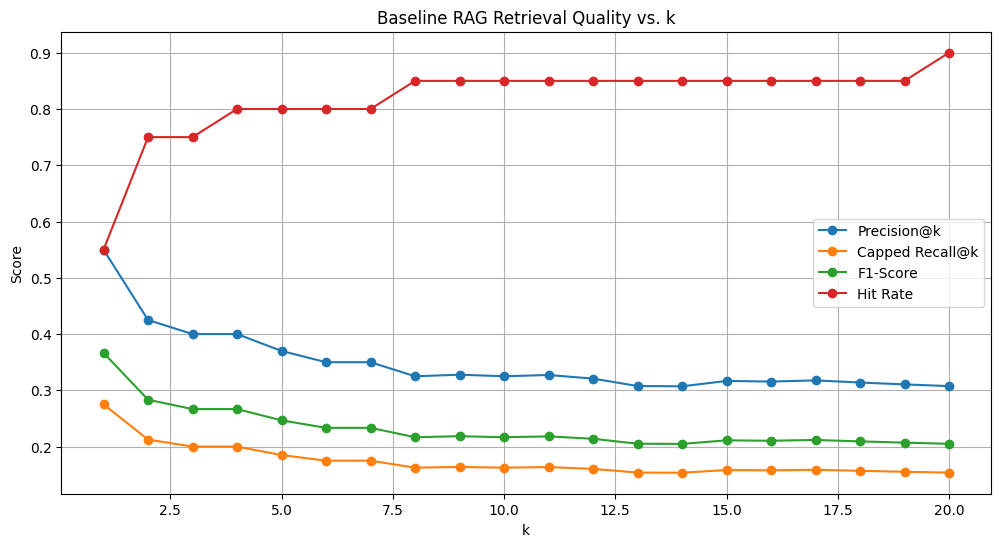

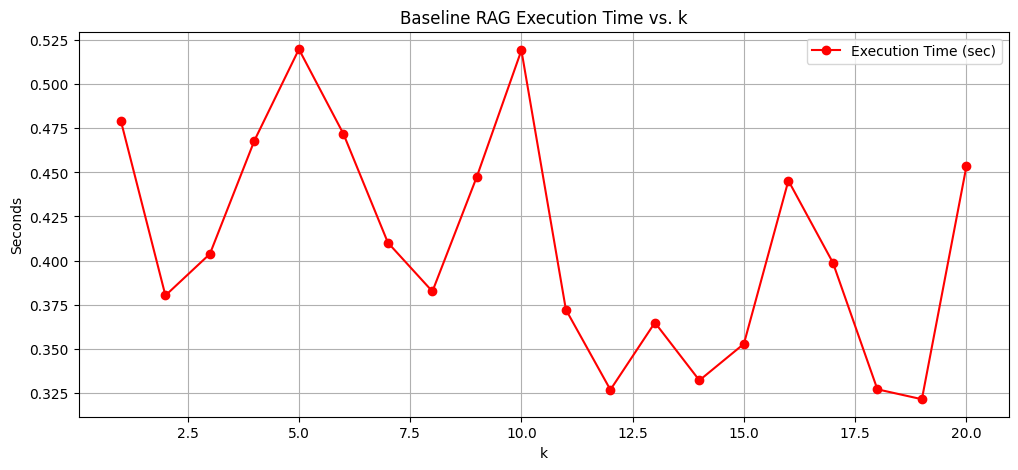

In [ ]:
tuning_results = tune_k(
    rag=test_base_rag,
    queries_df=test_queries.sample(n=20, random_state=42),
    evaluation_df=evaluation_df,
    k_range=range(1, 21),
    title_prefix="Baseline RAG"
)

To identify an appropriate value of k for the baseline RAG, we analyze both retrieval quality and execution time, as shown in **Baseline RAG Retrieval Quality vs. k** and **Baseline RAG Execution Time vs. k** figures.

##### Retrieval Quality Behavior

The retrieval metrics exhibit a consistent and interpretable trend:
- **Hit Rate** increases steadily as k grows and reaches **0.85 at k = 8**, after which it plateaus and remains constant up to k = 19. At **k = 4**, the hit rate already reaches **0.8**, which is very close to the maximum observed value.
- **Precision@k**, **Capped Recall@k**, and **F1-score** decrease monotonically as k increases, reflecting the inclusion of more marginally relevant or irrelevant chunks. These quality-oriented metrics achieve **higher values at smaller k**, particularly around k = 4, before gradually stabilizing at lower levels for larger k values.

This behavior indicates that:
- Increasing k improves the likelihood of retrieving at least one relevant document, but the marginal gain beyond **k = 4** is small.
- Larger k values introduce additional retrieved chunks that do not significantly improve recall or hit rate, while consistently reducing precision and F1-score.

##### Execution Time Characteristics

Execution time does not follow a strictly monotonic trend with respect to k:
- Runtime fluctuates across different values of k, rather than increasing linearly.
- However, the overall variation is limited, with a maximum difference of approximately 0.2 seconds across the entire range of k values.

This suggests that, within the tested range, execution time is not the dominant factor in selecting k, and retrieval quality should be prioritized.

##### Final Choice of k

Based on these observations:

- k = 4 provides a strong trade-off between retrieval completeness and result quality:
    - Hit rate at k = 4 (0.8) is close to the maximum achieved at higher k values.
    - Precision, capped recall, and F1-score are higher at k = 4 than at larger values of k.
- Increasing k beyond 4 yields **diminishing returns** in hit rate while introducing additional noise into the retrieved set.

Therefore, **k = 4** is selected as the optimal retrieval size for the baseline RAG, striking a balance between retrieval completeness and result quality while maintaining stable execution time.

This value is adopted as the default configuration for the baseline RAG in subsequent experiments.


#### 4.4.2. Graph RAG

In [ ]:
test_graph_rag = GraphRag(graph_store=graph_store, return_only_retrieval=True)

Evaluating k=1 ...
Evaluating k=2 ...
Evaluating k=3 ...
Evaluating k=4 ...
Evaluating k=5 ...
Evaluating k=6 ...
Evaluating k=7 ...
Evaluating k=8 ...
Evaluating k=9 ...
Evaluating k=10 ...
Evaluating k=11 ...
Evaluating k=12 ...
Evaluating k=13 ...
Evaluating k=14 ...
Evaluating k=15 ...
Evaluating k=16 ...
Evaluating k=17 ...
Evaluating k=18 ...
Evaluating k=19 ...
Evaluating k=20 ...


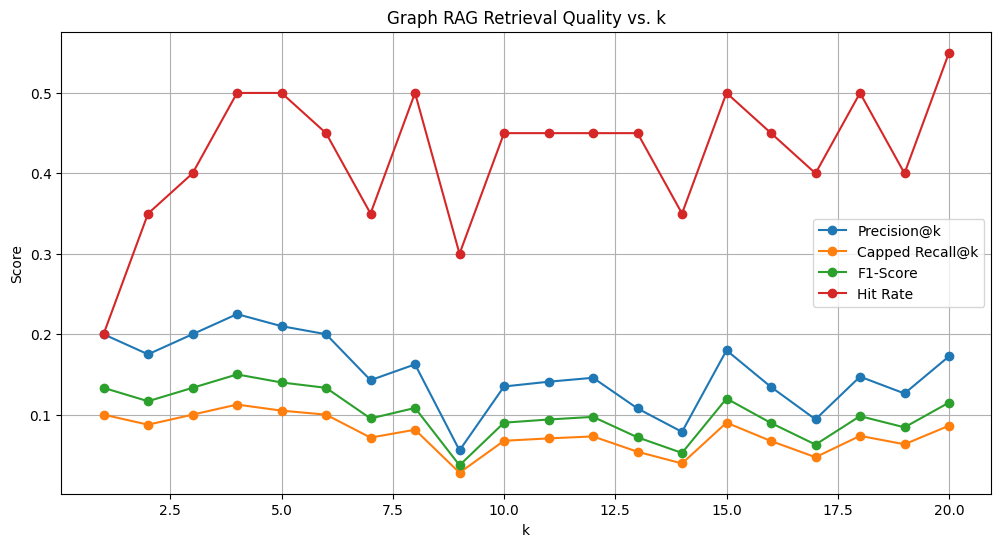

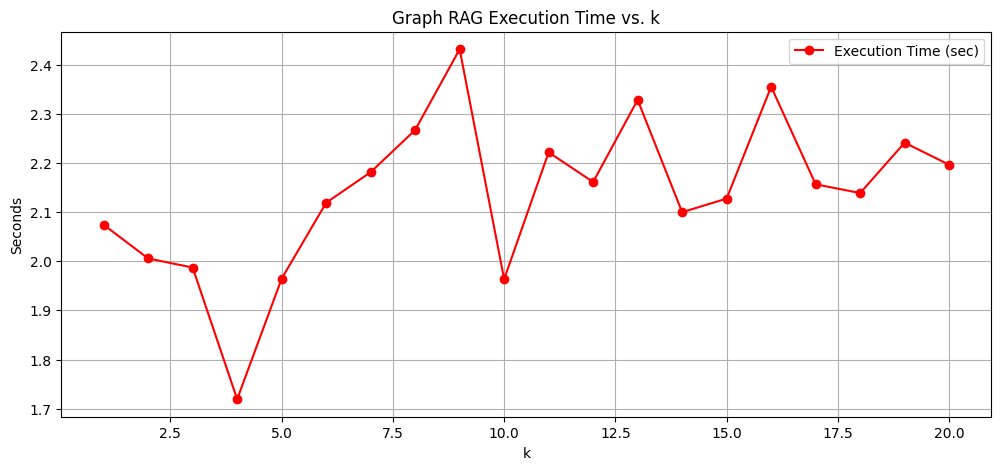

In [ ]:
tuning_results = tune_k(
    rag=test_graph_rag,
    queries_df=test_queries.sample(n=20, random_state=42),
    evaluation_df=evaluation_df,
    k_range=range(1, 21),
    title_prefix="Graph RAG"
)

##### Retrieval Quality Behavior

Unlike the baseline RAG, the retrieval metrics of Graph RAG exhibit non-monotonic and more volatile behavior across different values of k:
- **Hit Rate** increases rapidly for small k values and reaches 0.5 at k = 4 and k = 5. Beyond this point, hit rate does not improve consistently and instead fluctuates between **0.3 and 0.5** as k increases. A notable drop is observed at **k = 9**, where hit rate reaches **0.3**, representing one of the lowest values in the tested range.
- **Precision@k**, **Capped Recall@k**, and **F1-score** achieve their **highest values at k = 4**, indicating the most effective retrieval configuration. The lowest values for these metrics occur around **k = 9**, aligning with the drop observed in hit rate. For k > 5, the metrics fluctuate without a clear upward or downward trend, suggesting instability in retrieval quality when more chunks are included.

This behavior indicates that:
- Graph-guided retrieval is **most effective at small k values**, where the graph structure helps focus retrieval on highly relevant chunks.
- Increasing k beyond this point introduces additional candidates that are not consistently beneficial, leading to fluctuating retrieval quality rather than systematic improvement.

##### Execution Time Characteristics
The execution time profile of Graph RAG differs substantially from the baseline RAG:
- The **lowest execution time**, approximately **1.7 seconds**, is observed at **k = 4**, coinciding with the peak retrieval quality.
- As k increases beyond 4, execution time **increases sharply** and then **fluctuates between approximately 2.0 and 2.4 seconds**.
These fluctuations suggest that graph traversal and candidate expansion introduce non-linear computational overhead as k grows. Compared to the baseline RAG, Graph RAG incurs significantly higher and more variable latency, making efficiency a more important consideration in parameter selection.

##### Final Choice of k

Based on these observations:

- k = 4 represents a clear optimal point for Graph RAG:
    - Highest hit rate and strongest precision, recall, and F1-score.
    - Lowest observed execution time.
- Larger values of k do not yield consistent improvements in retrieval quality and introduce additional latency and instability.

Therefore, **k = 4** is selected as the optimal retrieval size for the Graph RAG, providing the best balance between retrieval effectiveness and computational efficiency.

This value is adopted as the default configuration for Graph RAG in subsequent experiments.

#### 4.4.3. Agentic RAG

Based on the k-tuning results of both the Baseline RAG and Graph RAG, we observe that optimal retrieval performance is consistently achieved at relatively small values of k. Increasing k beyond this range yields limited or no improvements in retrieval effectiveness, while potentially increasing computational cost.

In addition, due to the characteristics of our document collection and the results of extensive empirical testing, which has been excluded from this notebook, we find that further query refinement in Agentic RAG beyond the second iteration is typically redundant and does not lead to meaningful retrieval improvements. This is particularly costly in our setting, as the Agentic RAG reformulation mechanism incorporates the full content of previously retrieved chunks into subsequent queries, substantially increasing the number of tokens processed by the language model.

Therefore, to balance retrieval quality, evaluation efficiency, and computational cost, we restrict the k-tuning of the Agentic RAG to a smaller search space, specifically k ∈ [1, 5], and limit the number of agentic refinement rounds to at most two. These design choices reduce unnecessary computation while remaining consistent with the empirical behavior observed in the Baseline and Graph RAG variants.

In [ ]:
test_agentic_rag = AgenticRag(max_rounds=2, return_only_retrieval=True)

Evaluating k=1 ...
Evaluating k=2 ...
Evaluating k=3 ...
Evaluating k=4 ...
Evaluating k=5 ...


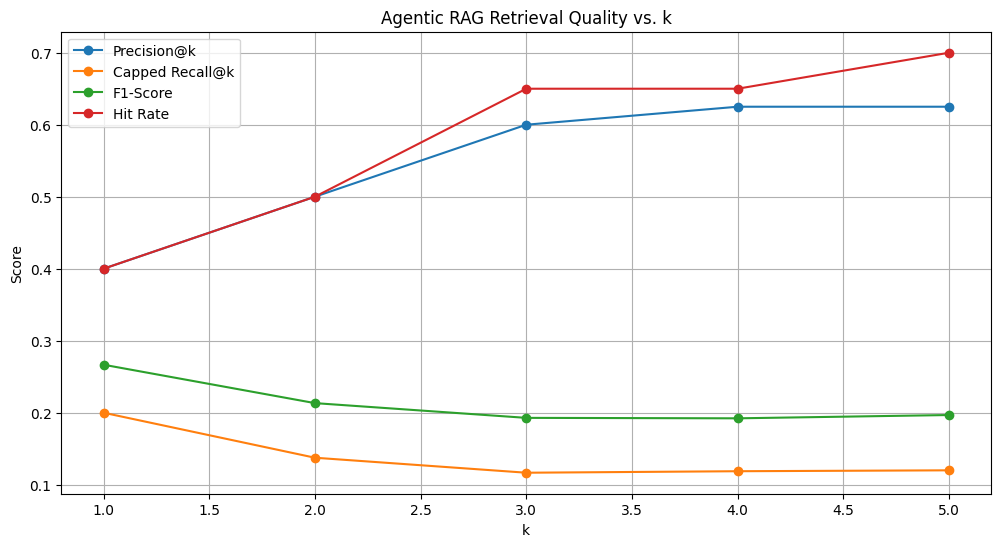

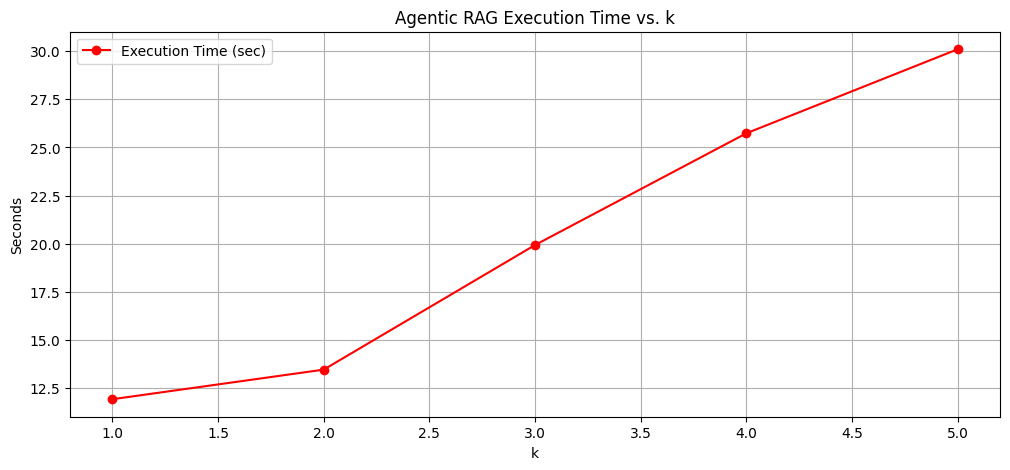

In [ ]:
tuning_results = tune_k(
    rag=test_agentic_rag,
    queries_df=test_queries.sample(n=20, random_state=42),
    evaluation_df=evaluation_df,
    k_range=range(1, 6),
    title_prefix="Agentic RAG"
)

##### Retrieval Quality Behavior

The retrieval behavior of Agentic RAG differs from both Baseline and Graph RAG due to its iterative, LLM-driven query reformulation mechanism:
- **Hit Rate** and **Precision@k** increase gradually as k increases from 1 to 5, indicating that retrieving more chunks slightly improves the likelihood of surfacing at least one relevant document and improves early-rank relevance.
- **Capped Recall@k** and **F1-score** decrease as k increases. This suggests that while more chunks are retrieved, the proportion of relevant information among them diminishes, leading to reduced overall balance between precision and recall.
- Importantly, all four metrics begin to **stabilize around k = 3**. Beyond this point, increasing k yields only marginal or negligible changes in retrieval quality, with no clear performance gains.

This behavior indicates that:
- Agentic RAG benefits from a moderate number of retrieved chunks to support effective query refinement.
- Retrieving additional chunks beyond a small k does not meaningfully improve retrieval effectiveness and may introduce unnecessary noise into the agent’s reasoning process.

##### Execution Time Characteristics

Execution time is a critical factor for Agentic RAG due to its multi-step, LLM-centric design:
- Execution time increases **substantially and monotonically** as k grows.
- A notable jump in latency is observed when k increases from 2 to 3, and the runtime continues to rise sharply for k = 4 and k = 5.
- This increase is expected, as larger k values lead to more retrieved content being injected into intermediate prompts, significantly increasing token counts and LLM inference cost.

Compared to Baseline and Graph RAG, Agentic RAG exhibits much higher sensitivity to k in terms of computational overhead, making efficiency a key consideration in parameter selection.

##### Final Choice of k

Based on these observations:

- k = 3 represents the most balanced configuration:
    - Hit rate and precision are already close to their maximum values.
    - Recall and F1-score have not yet degraded significantly.
    - Execution time remains substantially lower than at higher k values.
- Increasing k beyond 3 introduces **disproportionately higher computational cost** without yielding meaningful improvements in retrieval effectiveness.

Therefore, **k = 3** is selected as the optimal retrieval size for Agentic RAG, striking an effective balance between retrieval performance and computational efficiency.

This value is adopted as the default configuration for Agentic RAG in subsequent experiments.


#### 4.4.4. Hybrid RAG

Consistent with the Agentic RAG configuration, the k range for tuning the Hybrid RAG is limited to k ∈ [1, 5] to balance retrieval effectiveness and computational efficiency.

In [ ]:
test_hybrid_rag = HybridRag(agentic_rag=test_agentic_rag, graph_rag=test_graph_rag, return_only_retrieval=True)

Evaluating k=1 ...
Evaluating k=2 ...
Evaluating k=3 ...
Evaluating k=4 ...
Evaluating k=5 ...


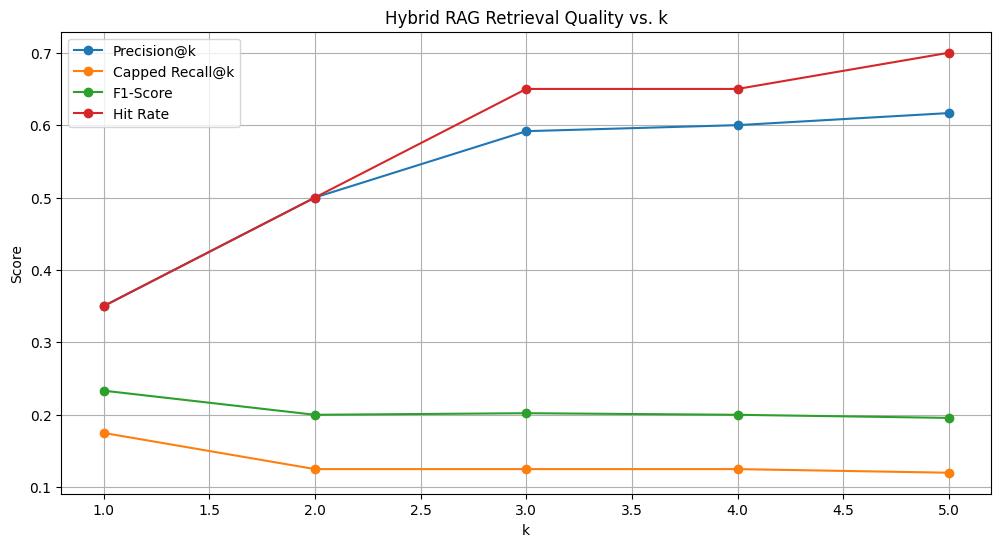

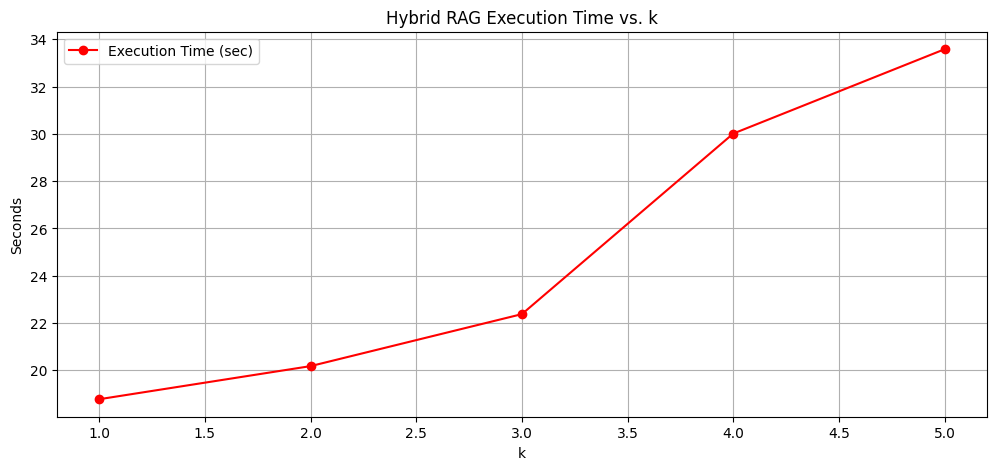

In [ ]:
tuning_results = tune_k(
    rag=test_hybrid_rag,
    queries_df=test_queries.sample(n=20, random_state=42),
    evaluation_df=evaluation_df,
    k_range=range(1, 6),
    title_prefix="Hybrid RAG"
)

The k-tuning results of the Hybrid RAG closely mirror those observed for the Agentic RAG. Retrieval quality metrics exhibit similar trends, with hit rate and precision increasing slightly as k grows, while capped recall and F1-score decrease. Notably, all metrics stabilize around k = 3, beyond which further increases in k yield negligible improvements in retrieval effectiveness. At the same time, execution time increases substantially for k > 3 due to the expanded amount of retrieved content being incorporated into the agentic reasoning process. Consequently, **k = 3** is selected as the optimal retrieval size for Hybrid RAG, balancing retrieval effectiveness and computational efficiency.

### 4.5. Evaluate All RAGs

In [ ]:
test_rag_config = {
    "BaseRAG": {
        "rag": test_base_rag,
        "k": 4
    },
    "GraphRAG": {
        "rag": test_graph_rag,
        "k": 4
    },
    "AgenticRAG": {
        "rag": test_agentic_rag,
        "k": 3
    },
    "HybridRAG": {
        "rag": test_hybrid_rag,
        "k": 3
    }
}

In [ ]:
def evaluate_all_rags(rag_config, queries_df, evaluation_df):
    """
    Evaluate a list of RAG models using their optimal k values.

    Parameters:
        rag_config      : dictionary that maps model_name -> {"rag": instance, "k": int}
        queries_df      : evaluation queries dataframe
        evaluation_df   : ground truth corpus

    Returns:
        DataFrame of mean scores per model
    """
    results = []

    for model_name, cfg in rag_config.items():
        rag = cfg["rag"]
        k = cfg["k"]

        print(f"\nEvaluating {model_name} with k={k}...")

        mean_scores = evaluate_query_dataframe(
            rag=rag,
            queries_df=queries_df,
            k=k,
            evaluation_df=evaluation_df
        )

        mean_scores["model"] = model_name
        mean_scores["k"] = k
        results.append(mean_scores)

    return pd.DataFrame(results)

In [ ]:
results_df = evaluate_all_rags(
    rag_config=test_rag_config,
    queries_df=test_queries,
    evaluation_df=evaluation_df
)

results_df


Evaluating BaseRAG with k=4...

Evaluating AgenticRAG with k=3...

Evaluating GraphRAG with k=4...

Evaluating HybridRAG with k=3...


,precision,capped_recall,f1,hit_rate,execution_time,model,k
0,0.432500,0.216250,0.288333,0.720,0.768184,BaseRAG,4
1,0.575833,0.160000,0.243353,0.615,20.883049,AgenticRAG,3
2,0.198750,0.099375,0.132500,0.310,1.825789,GraphRAG,4
3,0.583333,0.158333,0.241984,0.625,24.288085,HybridRAG,3


In [ ]:
results_output_path = "rag_evaluation_results.csv"

results_df.to_csv(
    results_output_path,
    index=False,
    encoding="utf-8"
)

print(f"✅ Results exported to {results_output_path}")

✅ Results exported to rag_evaluation_results.csv


### 4.6. Visualize All RAG's Performance

In [ ]:
def visualize_rag_scores(results_df):
    """
    Visualize RAG evaluation scores and execution time.
    - Retrieval quality metrics are shown in a grouped bar chart
    - Execution time is shown in a separate plot
    """

    # ---------------------------
    # 1. Retrieval quality plot
    # ---------------------------
    metrics = ["precision", "capped_recall", "f1", "hit_rate"]
    models = results_df["model"].tolist()
    x = np.arange(len(models))
    width = 0.2

    plt.figure(figsize=(14, 7))

    for idx, metric in enumerate(metrics):
        plt.bar(
            x + idx * width,
            results_df[metric],
            width,
            label=metric
        )

    plt.xticks(x + width * (len(metrics) - 1) / 2, models)
    plt.ylabel("Score")
    plt.title("RAG Model Comparison – Retrieval Quality")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

    # ---------------------------
    # 2. Execution time plot
    # ---------------------------
    plt.figure(figsize=(10, 5))

    plt.bar(
        models,
        results_df["execution_time"],
    )

    plt.ylabel("Seconds")
    plt.title("RAG Model Comparison – Execution Time")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()


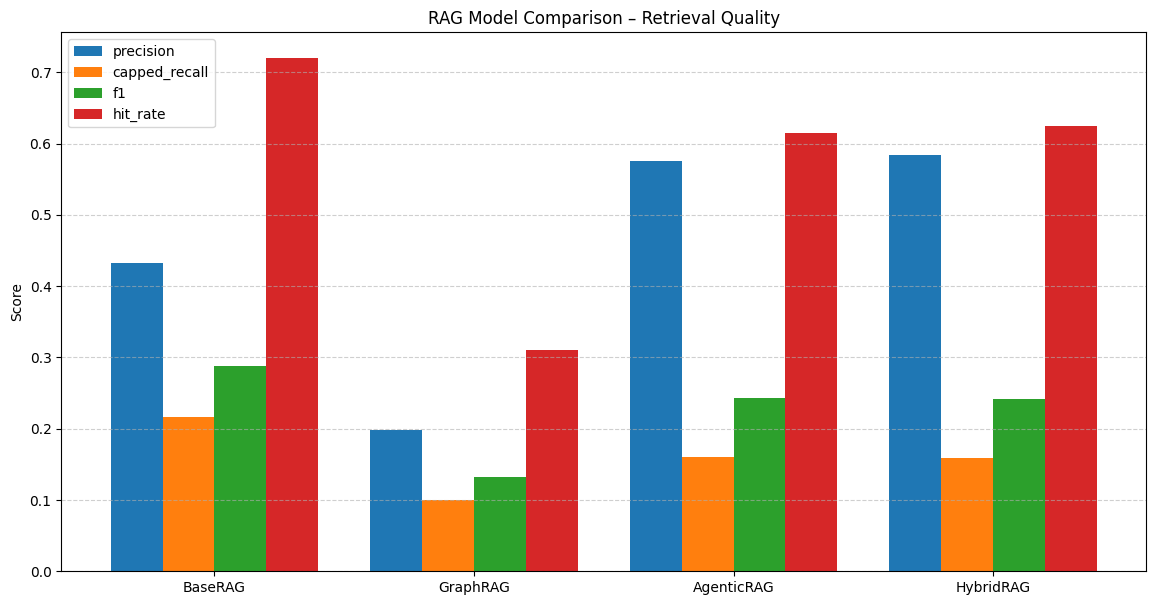

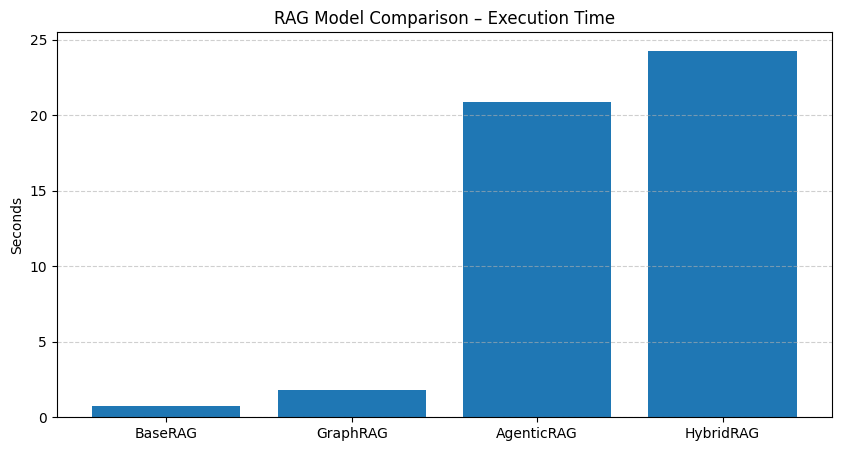

In [ ]:
visualize_rag_scores(results_df)

The experimental results reveal clear trade-offs between retrieval effectiveness and computational cost across the four evaluated RAG architectures.

**Baseline RAG** achieves a strong balance between effectiveness and efficiency. With the highest hit rate among all models (0.72) and competitive precision (0.43) and F1-score (0.29), it demonstrates reliable retrieval quality while maintaining very low execution time (≈0.77s). This indicates that simple dense retrieval is already highly effective for the dataset used.

**Graph RAG** exhibits the lowest retrieval performance across all metrics, with notably lower precision (0.20), F1-score (0.13), and hit rate (0.31). While it is computationally efficient (≈1.83s), the results indicate that graph-based structural constraints alone are insufficient to consistently surface relevant content for the evaluated queries.

**Agentic RAG** improves precision (0.58) compared to the baseline, reflecting better early-rank relevance due to LLM-driven query reformulation. However, this comes at a substantial computational cost, with execution time increasing by more than an order of magnitude (≈20.9s). Despite the higher cost, its overall retrieval balance (F1 ≈ 0.24, hit rate ≈ 0.62) does not surpass the baseline, suggesting diminishing returns from iterative reasoning in this setting.

**Hybrid RAG**, which combines graph retrieval with agentic reasoning, mirrors the behavior of Agentic RAG in terms of retrieval quality (precision ≈ 0.58, hit rate ≈ 0.63) but incurs the highest execution cost (≈24.3s). The lack of improvement over Agentic RAG suggests that graph-retrieved chunks are frequently deemed insufficient by the LLM, leading the system to rely primarily on iterative reformulation rather than benefiting from graph guidance.

## 5. Conclusion

This study systematically investigated the effectiveness and efficiency of multiple Retrieval-Augmented Generation (RAG) architectures—**Baseline RAG**, **Graph RAG**, **Agentic RAG**, and **Hybrid RAG**—within the context of large-scale digital archive retrieval. Through controlled *k*-tuning experiments and a consistent evaluation protocol, we examined how increasing architectural complexity affects retrieval quality, computational cost, and practical usability.

The experimental results demonstrate that **retrieval effectiveness is highly sensitive to small values of *k***, regardless of architectural sophistication. Across all RAG variants, optimal or near-optimal performance consistently emerged when *k* remained within a narrow range (typically *k ≤ 5*). Increasing *k* beyond this range rarely yielded meaningful improvements in retrieval quality and, in several cases, introduced instability or degradation in key metrics such as **precision**, **capped recall**, and **F1-score**. This behavior is likely influenced by the characteristics of the underlying dataset, including topic density and document distribution.

The **Baseline RAG** established a strong and reliable performance benchmark, achieving a high hit rate and competitive balanced metrics with minimal execution time. This indicates that dense vector retrieval alone can be highly effective for the evaluated dataset, particularly when paired with appropriate document chunking and high-quality embeddings. However, while Baseline RAG appears to achieve higher recall under topic-based evaluation, its lower precision suggests that it is less effective at filtering out irrelevant or weakly related content. This implies a higher risk of *context poisoning*, where retrieved documents share the same topic label but do not meaningfully contribute to answering the query.

The **Graph RAG** experiments revealed that graph-guided retrieval can be effective when constrained to small *k* values but becomes increasingly volatile as *k* grows. While the graph structure helps focus retrieval at low *k*, expanding the candidate set often introduces noise and inconsistent traversal behavior, leading to fluctuating retrieval quality. Importantly, the relatively low performance of Graph RAG in this study may be largely attributable to how the knowledge graph was constructed and queried. Specifically, concepts were extracted using an LLM and matched exactly against graph nodes; if the extracted concepts from a query did not exist in the graph, no documents were returned. This strict matching strategy likely limited recall and robustness. Given the strong theoretical potential of Graph RAG, future work should explore improved knowledge base construction, richer concept linking, and similarity-based or fuzzy matching strategies to better leverage graph structures.

The **Agentic RAG** introduced an additional layer of reasoning through iterative query reformulation and chunk filtering. Although this approach produced gradual improvements in hit rate and precision, the gains were modest relative to the substantial increase in execution time. Retrieval quality metrics stabilized early, indicating that retrieving additional chunks beyond a small *k* provides limited benefit for the agent’s reasoning process while significantly increasing computational overhead due to larger prompt sizes and repeated LLM calls.

Finally, the **Hybrid RAG**, which combines graph-based retrieval with agentic reasoning, exhibited behavior closely aligned with Agentic RAG. This suggests that graph-retrieved chunks were frequently deemed insufficient by the LLM critic, causing the system to rely primarily on iterative reformulation rather than benefiting from graph structure. Consequently, the hybrid approach did not yield additive improvements in retrieval effectiveness and incurred the highest computational cost among all evaluated variants.

An important practical consideration emerging from this study is **computational and monetary cost**, which was not explicitly quantified in the evaluation metrics. Although not discussed in detail earlier, the cost of building the underlying infrastructure—including **embedding generation, document classification, and concept extraction for graph construction**, as well as repeated tuning and evaluation—was substantial relative to the dataset size. Specifically, processing only **2,293 documents incurred an estimated cost of approximately USD 100**, primarily due to repeated LLM-based operations.

This observation highlights a critical scalability concern. In future studies, particularly when extending the system to **large-scale multimodal collections** such as real HCMUT digital library materials, lecture recordings, or scanned archival documents, **cost optimization will become a first-class design constraint**. Architectural choices that appear viable at small scale may become prohibitively expensive when applied to tens of thousands of documents or continuous data ingestion pipelines. Consequently, future evaluations should incorporate **explicit cost-aware metrics**, capturing not only retrieval effectiveness and latency but also **embedding cost, LLM invocation cost, and overall system efficiency**, to enable more realistic and deployable RAG system designs.

Overall, the findings highlight a critical insight: **increased architectural complexity does not necessarily translate to better retrieval performance**. For the evaluated digital archive setting, **simpler retrieval pipelines—when carefully tuned—can outperform more complex architectures when both effectiveness and efficiency are considered**. At the same time, the results also point to clear directions for future work. The limited gains from increasing *k* may be influenced by the relatively small subset of documents used in this study; extending experiments to the full dataset of 51,856 documents could reveal different retrieval dynamics. Moreover, the topic-based evaluation protocol provides only a coarse approximation of relevance. More fine-grained, content-level relevance judgments will be necessary to fully assess the strengths and weaknesses of different RAG variants.

These findings underscore the importance of empirical evaluation, cost-aware design, and principled parameter selection when developing advanced RAG systems for real-world digital archive retrieval, while also highlighting the significant potential for future improvements in graph construction, semantic matching, and evaluation methodology.
